# 10C — Standard Box-Guided Finding Attention — ResNet50-320 + Focal — λfinding 0.5 — λbox 0.01 — Seed 42

**Project:** Pedi-CGAM Lite  
**Experiment ID:** `M06_BoxGuidedAttention_Lambda001_Seed42`  
**Platform:** Kaggle  
**Target GPU:** Single NVIDIA T4  

## Scientific question

> Does explicit radiologist bounding-box supervision improve finding localization while preserving or improving the frozen disease-classification objective, beyond the best Stage-09 multitask setting?

This notebook is the **third controlled spatial-supervision experiment**. Stage 10A (`λbox = 0.10`) and Stage 10B (`λbox = 0.05`) both produced large localization gains but reduced disease Macro-AUPRC. Because the raw box loss remained much larger than the disease loss, 10C reduces the box weight to `0.01` to test a more balanced classification–localization trade-off.

### Frozen from the executed Stage-09 work

- Backbone: **ResNet50**
- Image size: **320 × 320**
- Disease loss: **Binary Focal Loss, γ = 2**
- Finding loss: **Binary Focal Loss, γ = 2**
- Finding auxiliary weight: **λfinding = 0.50**
- Seed: **42**
- Frozen Stage-02 split
- Primary checkpoint metric: **validation 14-pathology Macro-AUPRC**
- Calibration split: **untouched**
- Official test set: **sealed**
- Numeric `class_id`: **not used**

### New variable in 10C

- Radiologist boxes are used for **finding-specific spatial supervision**
- Box attention loss weight: **λbox = 0.01**

The box loss is applied **only** to positive local findings with a valid radiologist box.

## Standard box-guided attention design

Because the finding head is a linear classifier after global average pooling, we can form a direct class-specific activation map from the final ResNet50 spatial feature map and the finding-head weights.

For each boxed finding:

1. Create a spatial attention distribution from its class activation map.
2. Rasterize the radiologist box annotation into a target mask.
3. Measure how much attention probability lies inside the box.
4. Penalize low attention mass inside the annotated region.

The total objective is:

**Disease focal loss + 0.50 × Finding focal loss + 0.01 × Box-attention loss**

### Localization evaluation

This notebook reports:

- **Attention mass inside radiologist boxes**
- **Pointing-game accuracy**
- Per-finding localization results
- A direct localization comparison against the executed **09A / M01 no-box multitask checkpoint**

This is important: Stage 10 must prove that box supervision changes spatial behavior, not merely classification metrics.

### Planned box-weight study

`0.01` is the low box-supervision run, motivated by the observation that the raw box loss remained much larger than the disease loss even at `λbox = 0.05`. This setting is intended to make the weighted box contribution comparable to the disease/finding objectives while still testing whether localization can improve.

- `10A: λbox = 0.10` (completed)
- `10B: λbox = 0.05` (completed)
- `10C: λbox = 0.01` (this notebook)

Do **not** tune these using the official test set.


In [1]:
# ============================================================
# 1. Install DICOM decoders BEFORE importing pydicom
# ============================================================
%pip install -q -U "pylibjpeg[all]" pyjpegls

print("✅ DICOM decoder packages ready.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 80.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 272.3/272.3 kB 15.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
✅ DICOM decoder packages ready.


In [2]:
# ============================================================
# 2. Imports, configuration, reproducibility
# ============================================================
import os
import sys
import gc
import io
import json
import time
import math
import random
import shutil
import hashlib
import zipfile
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pydicom
from pydicom.pixels import apply_modality_lut, apply_voi_lut

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode
from torchvision.models import resnet50, ResNet50_Weights

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    f1_score,
    recall_score,
    confusion_matrix,
)

from tqdm.auto import tqdm

# -------------------------------
# Frozen experiment configuration
# -------------------------------
EXPERIMENT_ID = "M06_BoxGuidedAttention_Lambda001_Seed42"
BASELINE_EXPERIMENT_ID = "M01_DiseaseFinding_Multitask_Seed42"

SEED = 42
IMAGE_SIZE = 320
BOX_MASK_SIZE = 80

BATCH_SIZE = 8
NUM_WORKERS = 4
MAX_EPOCHS = 25
EARLY_STOPPING_PATIENCE = 5
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
FIXED_THRESHOLD = 0.5
USE_AMP = True

FOCAL_GAMMA = 2.0
FINDING_LOSS_WEIGHT = 0.50
BOX_LOSS_WEIGHT = 0.01

# Executed 09A validation result. Used only as a checkpoint-loading sanity check.
EXPECTED_M01_PATHOLOGY14_AUPRC = 0.208471
M01_REPRO_TOLERANCE = 5e-4

EXPECTED_SPLIT_MANIFEST_SHA256 = (
    "3d2f8de854c9f61382b1ef5594264af739fcb1d3d9ca8ca9fe8d388380363770"
)

OUTPUT_DIR = Path(f"/kaggle/working/PediCGAM/{EXPERIMENT_ID}")
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
CACHE_DIR = Path(
    f"/kaggle/working/PediCGAM_cache/{EXPERIMENT_ID}_{IMAGE_SIZE}"
)

for d in [OUTPUT_DIR, FIG_DIR, TABLE_DIR, CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Reproducibility is preferred over maximum speed for controlled ablation.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("pydicom:", pydicom.__version__)
print("Device:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    props = torch.cuda.get_device_properties(0)
    print(f"GPU memory: {props.total_memory / 1024**3:.2f} GB")
else:
    raise RuntimeError(
        "GPU is not active. In Kaggle Settings, select a GPU accelerator "
        "before running Stage 10."
    )


Python: 3.12.13
PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
pydicom: 3.0.2
Device: cuda
GPU: Tesla T4
GPU memory: 14.56 GB


# 3. Required Kaggle inputs

Attach **three inputs**:

1. **VinDr-PCXR dataset**
2. **Stage 02 frozen split output**, either extracted or:
   - `PediCGAM_Stage02_Fixed_Split_All_Outputs.zip`
3. **09A / M01 output** containing the no-box multitask checkpoint:
   - `M01_DiseaseFinding_Multitask_Seed42_All_Outputs.zip`
   - or the extracted 09A notebook output containing `best_model.pth`

Why is 09A needed?

Stage 10 will evaluate the exact frozen **no-box multitask model** on the same validation bounding boxes before training the new box-guided model. This gives a clean localization baseline for:

- attention mass inside boxes
- pointing-game accuracy

The 09A checkpoint is **not** used to initialize Stage 10 training.  
The Stage-10 model still trains **fresh from ImageNet weights**.

The notebook refuses to continue if:

- the Stage-02 split SHA-256 is wrong, or
- the attached 09A checkpoint is not the expected `M01` experiment.


In [3]:
# ============================================================
# 4. Locate VinDr-PCXR automatically
# ============================================================
KAGGLE_INPUT = Path("/kaggle/input")

def find_vindr_root(search_root=KAGGLE_INPUT):
    candidates = []

    for f in search_root.rglob("image_labels_train.csv"):
        folder = f.parent
        names = {p.name for p in folder.iterdir() if p.is_file()}
        score = sum(
            x in names
            for x in ["image_labels_train.csv", "annotations_train.csv"]
        )
        candidates.append((score, folder))

    candidates.sort(key=lambda x: (-x[0], len(str(x[1]))))
    return candidates

vindr_candidates = find_vindr_root()

if not vindr_candidates:
    raise FileNotFoundError(
        "VinDr-PCXR was not found under /kaggle/input. "
        "Attach the VinDr-PCXR Kaggle dataset."
    )

DATA_ROOT = vindr_candidates[0][1]
TRAIN_DICOM_DIR = DATA_ROOT / "train"

assert TRAIN_DICOM_DIR.exists()

print("VinDr-PCXR root:")
print(DATA_ROOT)
print("\nTraining DICOM directory:")
print(TRAIN_DICOM_DIR)


VinDr-PCXR root:
/kaggle/input/datasets/kalloldaskushol/vindr-pcxr/Pediatric Chest X-ray/physionet.org/files/vindr-pcxr/1.0.0

Training DICOM directory:
/kaggle/input/datasets/kalloldaskushol/vindr-pcxr/Pediatric Chest X-ray/physionet.org/files/vindr-pcxr/1.0.0/train


In [4]:
# ============================================================
# 5. Locate and verify the FROZEN Stage 02 split manifest
# ============================================================
def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()

def find_frozen_manifest(search_root=KAGGLE_INPUT):
    direct_candidates = list(search_root.rglob("fixed_split_manifest.csv"))

    for p in direct_candidates:
        digest = sha256_file(p)
        if digest == EXPECTED_SPLIT_MANIFEST_SHA256:
            return p, "direct_csv", None

    for zip_path in search_root.rglob("*.zip"):
        try:
            with zipfile.ZipFile(zip_path, "r") as z:
                possible = [
                    n for n in z.namelist()
                    if n.endswith("fixed_split_manifest.csv")
                ]
                for member in possible:
                    raw = z.read(member)
                    digest = hashlib.sha256(raw).hexdigest()

                    if digest == EXPECTED_SPLIT_MANIFEST_SHA256:
                        extract_dir = Path(
                            "/kaggle/working/stage02_manifest_extracted"
                        )
                        extract_dir.mkdir(parents=True, exist_ok=True)
                        target = extract_dir / "fixed_split_manifest.csv"
                        target.write_bytes(raw)
                        return target, "zip", zip_path
        except zipfile.BadZipFile:
            continue

    return None, None, None

MANIFEST_PATH, MANIFEST_SOURCE, MANIFEST_CONTAINER = find_frozen_manifest()

if MANIFEST_PATH is None:
    raise FileNotFoundError(
        "The frozen Stage 02 fixed_split_manifest.csv was not found. "
        "Attach the saved Stage 02 output/ZIP."
    )

manifest_hash = sha256_file(MANIFEST_PATH)

print("Manifest:", MANIFEST_PATH)
print("Source type:", MANIFEST_SOURCE)
if MANIFEST_CONTAINER is not None:
    print("Found inside:", MANIFEST_CONTAINER)
print("SHA-256:", manifest_hash)

if manifest_hash != EXPECTED_SPLIT_MANIFEST_SHA256:
    raise RuntimeError(
        "STOP: split manifest hash does not match the frozen Stage 02 split."
    )

print("\n✅ FROZEN STAGE 02 SPLIT VERIFIED.")


Manifest: /kaggle/input/notebooks/kalloldaskushol/02-fixed-train-validation-calibration-split/PediCGAM/stage02_fixed_split/splits/fixed_split_manifest.csv
Source type: direct_csv
SHA-256: 3d2f8de854c9f61382b1ef5594264af739fcb1d3d9ca8ca9fe8d388380363770

✅ FROZEN STAGE 02 SPLIT VERIFIED.


In [5]:
# ============================================================
# 6. Locate the executed 09A / M01 no-box checkpoint
# ============================================================
M01_EXTRACT_DIR = Path("/kaggle/working/m01_checkpoint_extracted")
M01_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

def checkpoint_matches_m01(path):
    try:
        ckpt = torch.load(
            path,
            map_location="cpu",
            weights_only=False,
        )
        return (
            ckpt.get("experiment_id") == BASELINE_EXPERIMENT_ID
            and np.isclose(float(ckpt.get("finding_loss_weight")), 0.5)
            and ckpt.get("boxes_used") is False
            and ckpt.get("split_manifest_sha256")
                == EXPECTED_SPLIT_MANIFEST_SHA256
        )
    except Exception:
        return False

M01_CHECKPOINT_PATH = None
M01_CHECKPOINT_SOURCE = None

# A. Directly exposed notebook/dataset outputs.
for p in KAGGLE_INPUT.rglob("best_model.pth"):
    if checkpoint_matches_m01(p):
        M01_CHECKPOINT_PATH = p
        M01_CHECKPOINT_SOURCE = "direct"
        break

# B. ZIP input.
if M01_CHECKPOINT_PATH is None:
    for zip_path in KAGGLE_INPUT.rglob("*.zip"):
        try:
            with zipfile.ZipFile(zip_path, "r") as zf:
                members = [
                    n for n in zf.namelist()
                    if n.endswith("/best_model.pth")
                    or n == "best_model.pth"
                ]

                for member in members:
                    raw = zf.read(member)
                    target = M01_EXTRACT_DIR / "candidate_best_model.pth"
                    target.write_bytes(raw)

                    if checkpoint_matches_m01(target):
                        M01_CHECKPOINT_PATH = target
                        M01_CHECKPOINT_SOURCE = f"zip:{zip_path.name}"
                        break

                if M01_CHECKPOINT_PATH is not None:
                    break
        except zipfile.BadZipFile:
            continue

if M01_CHECKPOINT_PATH is None:
    raise FileNotFoundError(
        "Could not find the executed 09A / M01 checkpoint. "
        "Attach M01_DiseaseFinding_Multitask_Seed42_All_Outputs.zip "
        "or the extracted 09A notebook output."
    )

m01_checkpoint = torch.load(
    M01_CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)

print("✅ 09A / M01 checkpoint verified")
print("Checkpoint:", M01_CHECKPOINT_PATH)
print("Source:", M01_CHECKPOINT_SOURCE)
print("Experiment:", m01_checkpoint.get("experiment_id"))
print("Epoch:", m01_checkpoint.get("epoch"))
print(
    "Stored selection metric:",
    m01_checkpoint.get("selection_metric_value"),
)


✅ 09A / M01 checkpoint verified
Checkpoint: /kaggle/input/notebooks/kalloldaskushol/09a-disease-and-finding-multitask-seed42-fixed/PediCGAM/M01_DiseaseFinding_Multitask_Seed42/best_model.pth
Source: direct
Experiment: M01_DiseaseFinding_Multitask_Seed42
Epoch: 4
Stored selection metric: 0.20847144131991252


In [6]:
# ============================================================
# 7. Load labels and frozen split
# ============================================================
labels = pd.read_csv(DATA_ROOT / "image_labels_train.csv")
manifest = pd.read_csv(MANIFEST_PATH)

NON_LABEL_COLUMNS = ["image_id", "rad_ID"]
LABEL_COLUMNS = [
    c for c in labels.columns
    if c not in NON_LABEL_COLUMNS
]

assert len(LABEL_COLUMNS) == 15
assert "No finding" in LABEL_COLUMNS

PATHOLOGY_COLUMNS = [
    c for c in LABEL_COLUMNS
    if c != "No finding"
]

df = manifest.merge(
    labels,
    on="image_id",
    how="left",
    validate="one_to_one"
)

if df[LABEL_COLUMNS].isna().any().any():
    raise RuntimeError("Some manifest image IDs did not match label rows.")

split_counts = df["split"].value_counts()

print("Split counts:")
display(split_counts.to_frame("images"))

assert int(split_counts["train"]) == 5408
assert int(split_counts["validation"]) == 1159
assert int(split_counts["calibration"]) == 1161

train_df = df[df["split"] == "train"].copy().reset_index(drop=True)
val_df = df[df["split"] == "validation"].copy().reset_index(drop=True)

print("\nTraining images:", len(train_df))
print("Validation images:", len(val_df))
print(
    "Calibration images present in manifest but NOT used:",
    int(split_counts["calibration"]),
)

print("\n15 disease outputs:")
for i, c in enumerate(LABEL_COLUMNS, 1):
    print(f"{i:02d}. {c}")


Split counts:


,images
split,
train,5408
calibration,1161
validation,1159



Training images: 5408
Validation images: 1159
Calibration images present in manifest but NOT used: 1161

15 disease outputs:
01. No finding
02. Bronchitis
03. Brocho-pneumonia
04. Other disease
05. Bronchiolitis
06. Situs inversus
07. Pneumonia
08. Pleuro-pneumonia
09. Diagphramatic hernia
10. Tuberculosis
11. Congenital emphysema
12. CPAM
13. Hyaline membrane disease
14. Mediastinal tumor
15. Lung tumor


In [7]:
# ============================================================
# 8. Build image-level finding targets from class_name
# ============================================================
annotations = pd.read_csv(
    DATA_ROOT / "annotations_train.csv"
)

required_annotation_columns = {
    "image_id",
    "class_name",
    "x_min",
    "y_min",
    "x_max",
    "y_max",
}

missing_annotation_columns = (
    required_annotation_columns
    - set(annotations.columns)
)

if missing_annotation_columns:
    raise RuntimeError(
        "annotations_train.csv is missing required columns: "
        + str(sorted(missing_annotation_columns))
    )

# Use class_name, never numeric class_id.
annotation_class_names = (
    annotations["class_name"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

FINDING_CLASSES = (
    ["No finding"]
    + sorted(
        x
        for x in annotation_class_names
        if x != "No finding"
    )
)

assert len(FINDING_CLASSES) == 37
assert FINDING_CLASSES[0] == "No finding"

NO_FINDING_INDEX = FINDING_CLASSES.index("No finding")

FINDING_TARGET_COLUMNS = [
    f"finding_target_{i:02d}"
    for i in range(len(FINDING_CLASSES))
]

finding_matrix = pd.crosstab(
    annotations["image_id"].astype(str),
    annotations["class_name"].astype(str),
)

finding_matrix = (
    finding_matrix
    .reindex(
        columns=FINDING_CLASSES,
        fill_value=0,
    )
    .clip(upper=1)
    .astype(np.float32)
)

df["image_id_str"] = df["image_id"].astype(str)

for target_col, class_name in zip(
    FINDING_TARGET_COLUMNS,
    FINDING_CLASSES,
):
    df[target_col] = (
        df["image_id_str"]
        .map(finding_matrix[class_name])
        .fillna(0)
        .astype(np.float32)
    )

finding_row_sums = df[FINDING_TARGET_COLUMNS].sum(axis=1)

if (finding_row_sums <= 0).any():
    raise RuntimeError(
        "At least one frozen-split image has no finding annotation target."
    )

no_finding_target_col = FINDING_TARGET_COLUMNS[NO_FINDING_INDEX]
other_finding_target_cols = [
    c
    for c, name in zip(
        FINDING_TARGET_COLUMNS,
        FINDING_CLASSES,
    )
    if name != "No finding"
]

contradictory_finding_rows = (
    (df[no_finding_target_col] == 1)
    & (df[other_finding_target_cols].sum(axis=1) > 0)
)

if contradictory_finding_rows.any():
    raise RuntimeError(
        "Finding targets contain No finding together with another finding."
    )

train_df = (
    df[df["split"] == "train"]
    .copy()
    .reset_index(drop=True)
)
val_df = (
    df[df["split"] == "validation"]
    .copy()
    .reset_index(drop=True)
)

finding_class_map = pd.DataFrame({
    "finding_index": range(len(FINDING_CLASSES)),
    "class_name": FINDING_CLASSES,
    "target_column": FINDING_TARGET_COLUMNS,
})

finding_class_map.to_csv(
    TABLE_DIR / "finding_class_map.csv",
    index=False,
)

finding_frequency = pd.DataFrame({
    "class_name": FINDING_CLASSES,
    "train_positive_images": [
        int(train_df[c].sum())
        for c in FINDING_TARGET_COLUMNS
    ],
    "validation_positive_images": [
        int(val_df[c].sum())
        for c in FINDING_TARGET_COLUMNS
    ],
})

finding_frequency.to_csv(
    TABLE_DIR / "finding_label_frequencies.csv",
    index=False,
)

print("Finding outputs:", len(FINDING_CLASSES))
print("Actual local findings:", len(FINDING_CLASSES) - 1)
print("Numeric class_id used: NO")
display(finding_frequency)


Finding outputs: 37
Actual local findings: 36
Numeric class_id used: NO


,class_name,train_positive_images,validation_positive_images
0,No finding,3600,772
1,Anterior mediastinal mass,5,0
2,Aortic enlargement,1,0
3,Atelectasis,16,4
4,Boot-shaped heart,24,5
5,Bronchectasis,2,1
6,Bronchial thickening,393,84
7,Calcification,1,0
8,Cardiomegaly,113,24
9,Chest wall mass,2,0


In [8]:
# ============================================================
# 9. Build DICOM path map and verify every train/validation file
# ============================================================
dicom_paths = {
    p.stem: p
    for p in TRAIN_DICOM_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in {".dicom", ".dcm"}
}

required_ids = (
    set(train_df["image_id"].astype(str))
    | set(val_df["image_id"].astype(str))
)

missing_files = sorted(
    required_ids - set(dicom_paths.keys())
)

print("DICOM files indexed:", len(dicom_paths))
print("Train+validation IDs required:", len(required_ids))
print("Missing files:", len(missing_files))

if missing_files:
    print("Examples:", missing_files[:20])
    raise FileNotFoundError(
        "One or more frozen split images are missing from the DICOM directory."
    )

print("✅ All training and validation DICOM files are present.")


DICOM files indexed: 7728
Train+validation IDs required: 6567
Missing files: 0
✅ All training and validation DICOM files are present.


In [9]:
# ============================================================
# 10. Prepare VALID box annotations and normalize coordinates
# ============================================================
BOX_COLS = ["x_min", "y_min", "x_max", "y_max"]

box_numeric = annotations[BOX_COLS].apply(
    pd.to_numeric,
    errors="coerce",
)

valid_box_flag = (
    box_numeric.notna().all(axis=1)
    & (box_numeric["x_max"] > box_numeric["x_min"])
    & (box_numeric["y_max"] > box_numeric["y_min"])
    & (box_numeric[BOX_COLS] >= 0).all(axis=1)
)

valid_boxes = annotations.loc[
    valid_box_flag
].copy()

for c in BOX_COLS:
    valid_boxes[c] = box_numeric.loc[
        valid_box_flag, c
    ].astype(float)

# No box supervision for "No finding".
valid_boxes = valid_boxes[
    valid_boxes["class_name"].astype(str) != "No finding"
].copy()

valid_boxes["image_id"] = valid_boxes[
    "image_id"
].astype(str)

valid_boxes = valid_boxes[
    valid_boxes["image_id"].isin(required_ids)
].copy()

boxed_ids = sorted(
    valid_boxes["image_id"].unique().tolist()
)

print("Valid box rows in train+validation:", len(valid_boxes))
print("Unique boxed images in train+validation:", len(boxed_ids))

# Read only DICOM headers for boxed images to get source Rows / Columns.
dimension_rows = []
dimension_failures = []

for image_id in tqdm(
    boxed_ids,
    desc="Reading boxed-image dimensions",
):
    try:
        ds = pydicom.dcmread(
            str(dicom_paths[image_id]),
            stop_before_pixels=True,
            specific_tags=["Rows", "Columns"],
        )
        dimension_rows.append({
            "image_id": image_id,
            "rows": int(ds.Rows),
            "columns": int(ds.Columns),
        })
    except Exception as e:
        dimension_failures.append({
            "image_id": image_id,
            "error": f"{type(e).__name__}: {e}",
        })

if dimension_failures:
    display(pd.DataFrame(dimension_failures).head(20))
    raise RuntimeError(
        "Could not read DICOM dimensions for one or more boxed images."
    )

dimensions_df = pd.DataFrame(dimension_rows)

valid_boxes = valid_boxes.merge(
    dimensions_df,
    on="image_id",
    how="left",
    validate="many_to_one",
)

# Record out-of-bound source boxes before clipping.
out_of_bounds = (
    (valid_boxes["x_min"] < 0)
    | (valid_boxes["y_min"] < 0)
    | (valid_boxes["x_max"] > valid_boxes["columns"])
    | (valid_boxes["y_max"] > valid_boxes["rows"])
)

n_out_of_bounds = int(out_of_bounds.sum())

# Normalize and safely clip to [0, 1].
valid_boxes["nx_min"] = (
    valid_boxes["x_min"] / valid_boxes["columns"]
).clip(0, 1)
valid_boxes["nx_max"] = (
    valid_boxes["x_max"] / valid_boxes["columns"]
).clip(0, 1)
valid_boxes["ny_min"] = (
    valid_boxes["y_min"] / valid_boxes["rows"]
).clip(0, 1)
valid_boxes["ny_max"] = (
    valid_boxes["y_max"] / valid_boxes["rows"]
).clip(0, 1)

post_clip_valid = (
    (valid_boxes["nx_max"] > valid_boxes["nx_min"])
    & (valid_boxes["ny_max"] > valid_boxes["ny_min"])
)

if not post_clip_valid.all():
    bad = valid_boxes.loc[
        ~post_clip_valid,
        ["image_id", "class_name"] + BOX_COLS,
    ]
    display(bad.head(20))
    raise RuntimeError(
        "At least one valid source box became invalid after bounds clipping."
    )

finding_to_index = {
    name: i
    for i, name in enumerate(FINDING_CLASSES)
}

unknown_box_classes = sorted(
    set(valid_boxes["class_name"].astype(str))
    - set(FINDING_CLASSES)
)

if unknown_box_classes:
    raise RuntimeError(
        "Box classes are missing from FINDING_CLASSES: "
        + str(unknown_box_classes)
    )

# Keep normalized boxes in memory only. Do not export patient-level coordinates.
BOXES_BY_IMAGE = {}

for image_id, group in valid_boxes.groupby("image_id"):
    items = []

    for row in group.itertuples(index=False):
        class_name = str(row.class_name)
        class_index = finding_to_index[class_name]

        items.append((
            class_index,
            float(row.nx_min),
            float(row.ny_min),
            float(row.nx_max),
            float(row.ny_max),
        ))

    BOXES_BY_IMAGE[str(image_id)] = items

train_boxed_images = int(
    train_df["image_id"].astype(str).isin(BOXES_BY_IMAGE).sum()
)
val_boxed_images = int(
    val_df["image_id"].astype(str).isin(BOXES_BY_IMAGE).sum()
)

box_summary = pd.DataFrame([
    {
        "metric": "valid_box_rows_train_validation",
        "value": int(len(valid_boxes)),
    },
    {
        "metric": "unique_boxed_images_train_validation",
        "value": int(len(BOXES_BY_IMAGE)),
    },
    {
        "metric": "boxed_train_images",
        "value": train_boxed_images,
    },
    {
        "metric": "boxed_validation_images",
        "value": val_boxed_images,
    },
    {
        "metric": "out_of_bounds_rows_before_clipping",
        "value": n_out_of_bounds,
    },
])

box_summary.to_csv(
    TABLE_DIR / "box_annotation_summary.csv",
    index=False,
)

display(box_summary)
print("✅ Valid normalized box metadata prepared.")


Valid box rows in train+validation: 4433
Unique boxed images in train+validation: 2195


Reading boxed-image dimensions:   0%|          | 0/2195 [00:00<?, ?it/s]

,metric,value
0,valid_box_rows_train_validation,4433
1,unique_boxed_images_train_validation,2195
2,boxed_train_images,1808
3,boxed_validation_images,387
4,out_of_bounds_rows_before_clipping,0


✅ Valid normalized box metadata prepared.


In [10]:
# ============================================================
# 11. Load frozen pathology head / middle / tail groups
# ============================================================
def load_stage02_csv(filename):
    matches = list(KAGGLE_INPUT.rglob(filename))
    if matches:
        return pd.read_csv(matches[0])

    for zp in KAGGLE_INPUT.rglob("*.zip"):
        try:
            with zipfile.ZipFile(zp, "r") as z:
                members = [
                    n for n in z.namelist()
                    if n.endswith(filename)
                ]
                if members:
                    return pd.read_csv(
                        io.BytesIO(z.read(members[0]))
                    )
        except zipfile.BadZipFile:
            pass

    return None

rarity_groups = load_stage02_csv(
    "frozen_pathology_head_middle_tail_groups.csv"
)

if rarity_groups is None:
    raise FileNotFoundError(
        "Could not locate frozen_pathology_head_middle_tail_groups.csv "
        "from Stage 02."
    )

rarity_groups = rarity_groups[
    ["label", "positive_images", "frequency_rank", "rarity_group"]
].copy()

if set(rarity_groups["label"]) != set(PATHOLOGY_COLUMNS):
    raise RuntimeError(
        "Frozen pathology groups do not match the 14 pathology labels."
    )

GROUP_TO_LABELS = {
    group: rarity_groups.loc[
        rarity_groups["rarity_group"] == group,
        "label",
    ].tolist()
    for group in ["Head", "Middle", "Tail"]
}

print("Frozen pathology rarity groups:")
display(rarity_groups)


Frozen pathology rarity groups:


,label,positive_images,frequency_rank,rarity_group
0,Bronchitis,842,1,Head
1,Brocho-pneumonia,545,2,Head
2,Bronchiolitis,497,3,Head
3,Other disease,412,4,Head
4,Pneumonia,392,5,Head
5,Hyaline membrane disease,19,6,Middle
6,Tuberculosis,14,7,Middle
7,Situs inversus,11,8,Middle
8,Mediastinal tumor,8,9,Middle
9,Pleuro-pneumonia,6,10,Middle


# 12. Preprocessing and augmentation policy

The image preprocessing remains consistent with the executed 320×320 experiments:

1. Decode DICOM
2. Apply modality LUT when available
3. Apply VOI LUT when available
4. Correct `MONOCHROME1`
5. Clip 0.5th–99.5th intensity percentiles
6. Normalize to `[0, 1]`
7. Resize to `320 × 320`
8. Cache as uint8 grayscale
9. Training only:
   - ±5° affine rotation
   - ±3% translation
   - 0.95–1.05 scale
   - mild brightness/contrast jitter
10. Repeat grayscale to 3 channels
11. Apply the **same normalization values used by the executed Stage-09 notebooks**

### Box transformation rule

The training affine parameters are sampled **once per image** and applied jointly to:

- the image
- its box-derived target masks

Box masks are rasterized at `80 × 80` for memory efficiency. Their translation is scaled proportionally from the `320 × 320` image transform, then masks are pooled to the final ResNet50 feature-map resolution for attention loss.

### Anatomical safety

**No horizontal flip. No vertical flip.**

This remains important because `Situs inversus` is a disease label.


In [11]:
# ============================================================
# 13. DICOM preprocessing helper
# ============================================================
def dicom_to_uint8_320(path, output_size=IMAGE_SIZE):
    ds = pydicom.dcmread(str(path))

    arr = ds.pixel_array

    try:
        arr = apply_modality_lut(arr, ds)
    except Exception:
        arr = np.asarray(arr)

    try:
        arr = apply_voi_lut(arr, ds)
    except Exception:
        arr = np.asarray(arr)

    arr = np.asarray(arr, dtype=np.float32)

    if not np.isfinite(arr).all():
        finite = arr[np.isfinite(arr)]
        fill = float(np.median(finite)) if finite.size else 0.0
        arr = np.nan_to_num(
            arr,
            nan=fill,
            posinf=fill,
            neginf=fill,
        )

    if str(
        getattr(ds, "PhotometricInterpretation", "")
    ).upper() == "MONOCHROME1":
        arr = arr.max() + arr.min() - arr

    lo, hi = np.percentile(arr, [0.5, 99.5])

    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo = float(arr.min())
        hi = float(arr.max())

    if hi > lo:
        arr = np.clip(arr, lo, hi)
        arr = (arr - lo) / (hi - lo)
    else:
        arr = np.zeros_like(arr, dtype=np.float32)

    arr = (arr * 255.0).round().astype(np.uint8)

    img = Image.fromarray(arr)
    img = img.resize(
        (output_size, output_size),
        resample=Image.Resampling.BILINEAR,
    )

    return np.asarray(img, dtype=np.uint8)


In [12]:
# ============================================================
# 14. Cache preprocessed 320×320 train/validation images
# ============================================================
# Cache is outside the experiment ZIP.

def cache_images(dataframe, split_name):
    split_cache = CACHE_DIR / split_name
    split_cache.mkdir(parents=True, exist_ok=True)

    failures = []

    for image_id in tqdm(
        dataframe["image_id"].astype(str).tolist(),
        desc=f"Caching {split_name}",
    ):
        target = split_cache / f"{image_id}.npy"

        if target.exists():
            continue

        try:
            arr = dicom_to_uint8_320(
                dicom_paths[str(image_id)],
                IMAGE_SIZE,
            )
            np.save(target, arr, allow_pickle=False)
        except Exception as e:
            failures.append({
                "split": split_name,
                "image_id": image_id,
                "error": f"{type(e).__name__}: {e}",
            })

    return pd.DataFrame(failures)

train_cache_fail = cache_images(train_df, "train")
val_cache_fail = cache_images(val_df, "validation")

cache_failures = pd.concat(
    [train_cache_fail, val_cache_fail],
    ignore_index=True,
)

cache_failures.to_csv(
    TABLE_DIR / "preprocessing_cache_failures.csv",
    index=False,
)

print("Preprocessing failures:", len(cache_failures))

if len(cache_failures):
    display(cache_failures.head(30))
    raise RuntimeError(
        "Preprocessing failed for one or more images. "
        "Do not train until this is resolved."
    )

print("✅ Train and validation caches are complete.")


Caching train:   0%|          | 0/5408 [00:00<?, ?it/s]

Caching validation:   0%|          | 0/1159 [00:00<?, ?it/s]

Preprocessing failures: 0
✅ Train and validation caches are complete.


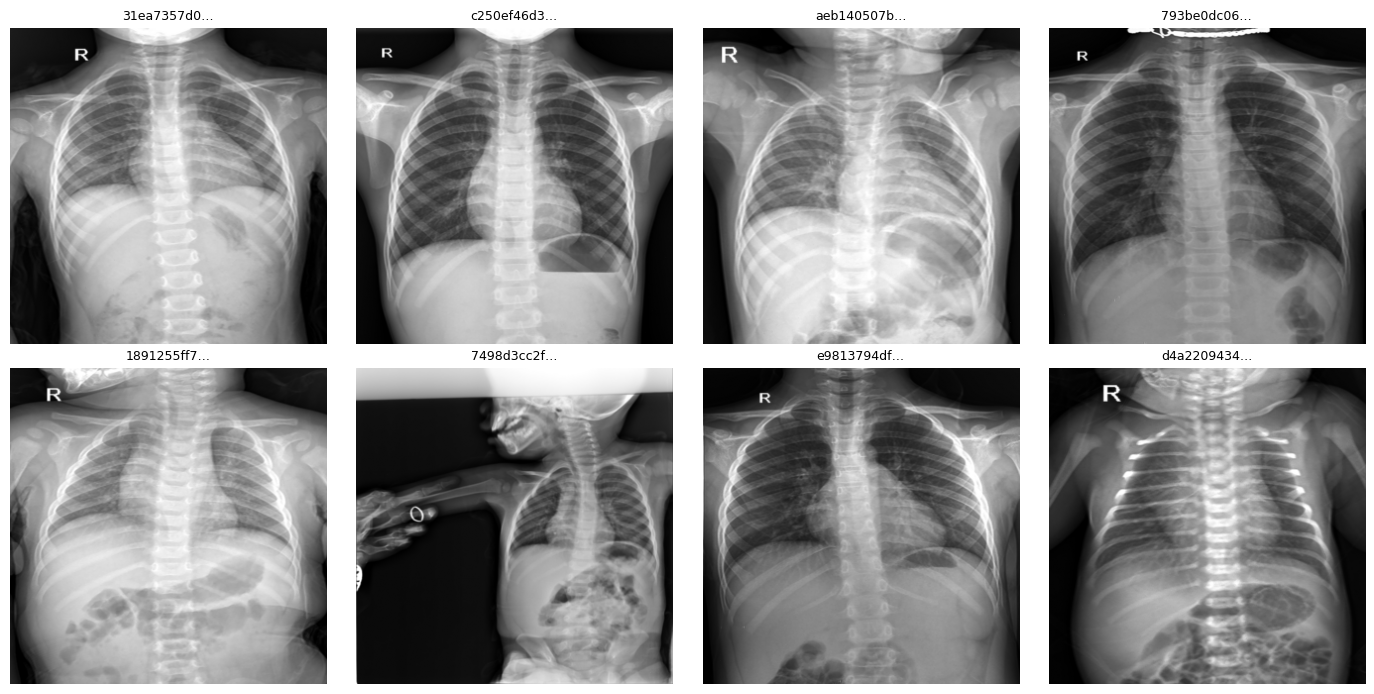

✅ Visual sanity check displayed but NOT exported.


In [13]:
# ============================================================
# 15. Visual preprocessing sanity check — DISPLAY ONLY
# ============================================================
# Restricted X-rays are intentionally NOT saved into the experiment ZIP.

sample_ids = (
    train_df["image_id"]
    .sample(n=min(8, len(train_df)), random_state=SEED)
    .astype(str)
    .tolist()
)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.ravel()

for ax, image_id in zip(axes, sample_ids):
    arr = np.load(
        CACHE_DIR / "train" / f"{image_id}.npy",
        allow_pickle=False,
    )
    ax.imshow(arr, cmap="gray")
    ax.set_title(str(image_id)[:10] + "…", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()
plt.close(fig)

print("✅ Visual sanity check displayed but NOT exported.")


In [14]:
# ============================================================
# 16. Joint image + box-mask transforms and Dataset
# ============================================================
# IMPORTANT:
# These normalization values are kept exactly as in the executed Stage-09
# notebooks so Stage 10 remains a controlled comparison.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.320, 0.225]

color_jitter = transforms.ColorJitter(
    brightness=0.10,
    contrast=0.10,
)

def rasterize_box_masks(image_id):
    masks = torch.zeros(
        (
            len(FINDING_CLASSES),
            BOX_MASK_SIZE,
            BOX_MASK_SIZE,
        ),
        dtype=torch.uint8,
    )

    for (
        class_index,
        nx_min,
        ny_min,
        nx_max,
        ny_max,
    ) in BOXES_BY_IMAGE.get(str(image_id), []):
        x1 = int(np.floor(nx_min * BOX_MASK_SIZE))
        y1 = int(np.floor(ny_min * BOX_MASK_SIZE))
        x2 = int(np.ceil(nx_max * BOX_MASK_SIZE))
        y2 = int(np.ceil(ny_max * BOX_MASK_SIZE))

        x1 = int(np.clip(x1, 0, BOX_MASK_SIZE - 1))
        y1 = int(np.clip(y1, 0, BOX_MASK_SIZE - 1))
        x2 = int(np.clip(x2, x1 + 1, BOX_MASK_SIZE))
        y2 = int(np.clip(y2, y1 + 1, BOX_MASK_SIZE))

        masks[
            class_index,
            y1:y2,
            x1:x2,
        ] = 1

    return masks


class JointTrainTransform:
    def __call__(self, image, box_masks):
        angle, translate, scale, shear = (
            transforms.RandomAffine.get_params(
                degrees=[-5.0, 5.0],
                translate=[0.03, 0.03],
                scale_ranges=[0.95, 1.05],
                shears=None,
                img_size=[IMAGE_SIZE, IMAGE_SIZE],
            )
        )

        # Match the executed Stage-09 RandomAffine default interpolation.
        image = TF.affine(
            image,
            angle=angle,
            translate=translate,
            scale=scale,
            shear=shear,
            interpolation=InterpolationMode.NEAREST,
            fill=0,
        )

        # Apply the same normalized geometry to the lower-resolution box masks.
        mask_translate = [
            int(round(translate[0] * BOX_MASK_SIZE / IMAGE_SIZE)),
            int(round(translate[1] * BOX_MASK_SIZE / IMAGE_SIZE)),
        ]

        box_masks = TF.affine(
            box_masks.float(),
            angle=angle,
            translate=mask_translate,
            scale=scale,
            shear=shear,
            interpolation=InterpolationMode.NEAREST,
            fill=0,
        )

        box_masks = (
            box_masks > 0.5
        ).to(torch.uint8)

        image = color_jitter(image)
        image = TF.normalize(
            image,
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
        )

        return image, box_masks


class JointValidationTransform:
    def __call__(self, image, box_masks):
        image = TF.normalize(
            image,
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
        )
        return image, box_masks


class CachedCXRBoxDataset(Dataset):
    def __init__(
        self,
        dataframe,
        split_name,
        cache_root,
        disease_label_columns,
        finding_target_columns,
        transform=None,
    ):
        self.df = dataframe.reset_index(drop=True)
        self.split_name = split_name
        self.cache_dir = Path(cache_root) / split_name
        self.disease_label_columns = disease_label_columns
        self.finding_target_columns = finding_target_columns
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_id = str(row["image_id"])

        arr = np.load(
            self.cache_dir / f"{image_id}.npy",
            allow_pickle=False,
        )

        x = (
            torch.from_numpy(arr)
            .float()
            .unsqueeze(0)
            / 255.0
        )
        x = x.repeat(3, 1, 1)

        disease_y = torch.tensor(
            row[self.disease_label_columns]
            .to_numpy(dtype=np.float32),
            dtype=torch.float32,
        )

        finding_y = torch.tensor(
            row[self.finding_target_columns]
            .to_numpy(dtype=np.float32),
            dtype=torch.float32,
        )

        box_masks = rasterize_box_masks(image_id)

        if self.transform is not None:
            x, box_masks = self.transform(
                x,
                box_masks,
            )

        box_present = (
            box_masks
            .flatten(1)
            .any(dim=1)
        )

        # "No finding" must never receive spatial box supervision.
        box_present[NO_FINDING_INDEX] = False

        return (
            x,
            disease_y,
            finding_y,
            box_masks,
            box_present,
            image_id,
        )


In [15]:
# ============================================================
# 17. DataLoaders and target-alignment checks
# ============================================================
train_dataset = CachedCXRBoxDataset(
    train_df,
    "train",
    CACHE_DIR,
    LABEL_COLUMNS,
    FINDING_TARGET_COLUMNS,
    transform=JointTrainTransform(),
)

val_dataset = CachedCXRBoxDataset(
    val_df,
    "validation",
    CACHE_DIR,
    LABEL_COLUMNS,
    FINDING_TARGET_COLUMNS,
    transform=JointValidationTransform(),
)

generator = torch.Generator()
generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    generator=generator,
    drop_last=False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=False,
)

batch = next(iter(train_loader))
(
    x,
    disease_y,
    finding_y,
    box_masks,
    box_present,
    ids,
) = batch

print("Batch image tensor:", x.shape, x.dtype)
print("Disease target tensor:", disease_y.shape)
print("Finding target tensor:", finding_y.shape)
print("Box masks:", box_masks.shape, box_masks.dtype)
print("Box-present flags:", box_present.shape, box_present.dtype)
print("Box-supervised pairs in sample batch:", int(box_present.sum()))

assert x.shape[1:] == (3, IMAGE_SIZE, IMAGE_SIZE)
assert disease_y.shape[1] == len(LABEL_COLUMNS)
assert finding_y.shape[1] == len(FINDING_CLASSES)
assert box_masks.shape[1:] == (
    len(FINDING_CLASSES),
    BOX_MASK_SIZE,
    BOX_MASK_SIZE,
)
assert box_present.shape[1] == len(FINDING_CLASSES)

# A box must imply a positive finding target after the joint transform.
bad_box_targets = (
    box_present
    & (finding_y <= 0.5)
)

if bad_box_targets.any():
    raise RuntimeError(
        "At least one box-supervised finding is not positive in the finding target."
    )

print("✅ DataLoader and box/finding alignment checks PASS.")


Batch image tensor: torch.Size([8, 3, 320, 320]) torch.float32
Disease target tensor: torch.Size([8, 15])
Finding target tensor: torch.Size([8, 37])
Box masks: torch.Size([8, 37, 80, 80]) torch.uint8
Box-present flags: torch.Size([8, 37]) torch.uint8
Box-supervised pairs in sample batch: 2
✅ DataLoader and box/finding alignment checks PASS.


In [16]:
# ============================================================
# 18. Spatial ResNet50 with disease + finding heads
# ============================================================
class SpatialDiseaseFindingResNet50(nn.Module):
    def __init__(
        self,
        pretrained_model,
        n_disease_labels,
        n_finding_labels,
    ):
        super().__init__()

        feature_dim = pretrained_model.fc.in_features
        pretrained_model.fc = nn.Identity()

        # Keep the same state_dict structure as executed 09A / M01.
        self.backbone = pretrained_model

        self.disease_head = nn.Linear(
            feature_dim,
            n_disease_labels,
        )
        self.finding_head = nn.Linear(
            feature_dim,
            n_finding_labels,
        )

    def extract_spatial_features(self, x):
        b = self.backbone

        x = b.conv1(x)
        x = b.bn1(x)
        x = b.relu(x)
        x = b.maxpool(x)

        x = b.layer1(x)
        x = b.layer2(x)
        x = b.layer3(x)
        x = b.layer4(x)

        return x

    def forward(self, x):
        feature_maps = self.extract_spatial_features(x)

        pooled = self.backbone.avgpool(
            feature_maps
        )
        pooled = torch.flatten(
            pooled,
            1,
        )

        disease_logits = self.disease_head(
            pooled
        )
        finding_logits = self.finding_head(
            pooled
        )

        return (
            disease_logits,
            finding_logits,
            feature_maps,
        )


def create_fresh_model():
    weights = ResNet50_Weights.DEFAULT

    try:
        pretrained = resnet50(weights=weights)
    except Exception as e:
        raise RuntimeError(
            "Could not load ImageNet-pretrained ResNet50 weights. "
            "Keep Kaggle Internet ON if the weights are not cached."
        ) from e

    return SpatialDiseaseFindingResNet50(
        pretrained_model=pretrained,
        n_disease_labels=len(LABEL_COLUMNS),
        n_finding_labels=len(FINDING_CLASSES),
    ).to(DEVICE)


In [17]:
# ============================================================
# 19. Focal loss + finding-specific CAM + box-attention loss
# ============================================================
class BinaryFocalLoss(nn.Module):
    def __init__(self, gamma=2.0, reduction="mean"):
        super().__init__()
        self.gamma = float(gamma)
        self.reduction = reduction

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            reduction="none",
        )

        probs = torch.sigmoid(logits)
        p_t = (
            probs * targets
            + (1.0 - probs)
            * (1.0 - targets)
        )

        focal_factor = (
            1.0 - p_t
        ).pow(self.gamma)

        loss = focal_factor * bce

        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss


def finding_attention_distribution(
    feature_maps,
    finding_head,
):
    # Direct class activation map from the linear finding-head weights.
    # Bias is spatially constant and therefore omitted.
    cams = torch.einsum(
        "kc,bchw->bkhw",
        finding_head.weight,
        feature_maps,
    )

    b, k, h, w = cams.shape

    attention = torch.softmax(
        cams.flatten(2),
        dim=-1,
    ).view(
        b, k, h, w
    )

    return attention


def box_attention_loss_and_stats(
    feature_maps,
    finding_head,
    finding_targets,
    box_masks,
    box_present,
    eps=1e-6,
):
    attention = finding_attention_distribution(
        feature_maps,
        finding_head,
    )

    h, w = attention.shape[-2:]

    target_masks = F.adaptive_max_pool2d(
        box_masks.float(),
        output_size=(h, w),
    )

    target_masks = (
        target_masks > 0
    ).float()

    valid = (
        box_present.bool()
        & (finding_targets > 0.5)
    )

    valid[:, NO_FINDING_INDEX] = False

    attention_mass = (
        attention
        * target_masks
    ).sum(dim=(-2, -1))

    valid_count = int(
        valid.sum().detach().cpu()
    )

    if valid_count > 0:
        selected_mass = attention_mass[
            valid
        ].clamp(
            min=eps,
            max=1.0,
        )

        box_loss = -torch.log(
            selected_mass
        ).mean()
    else:
        # Keep a graph-connected zero.
        box_loss = (
            feature_maps.sum()
            * 0.0
        )

    # Pointing game: strongest attention cell must fall inside the target box mask.
    flat_attention = attention.flatten(2)
    flat_masks = target_masks.flatten(2)

    max_indices = flat_attention.argmax(
        dim=-1,
        keepdim=True,
    )

    pointing_hit = flat_masks.gather(
        dim=2,
        index=max_indices,
    ).squeeze(-1)

    mask_area_fraction = target_masks.mean(
        dim=(-2, -1)
    )

    return {
        "loss": box_loss,
        "valid": valid,
        "attention_mass": attention_mass,
        "pointing_hit": pointing_hit,
        "mask_area_fraction": mask_area_fraction,
    }


# Synthetic preflight.
_test_features = torch.randn(
    2, 2048, 10, 10,
    device=DEVICE,
)
_test_head = nn.Linear(
    2048,
    len(FINDING_CLASSES),
).to(DEVICE)

_test_finding_targets = torch.zeros(
    2,
    len(FINDING_CLASSES),
    device=DEVICE,
)
_test_finding_targets[0, 1] = 1
_test_finding_targets[1, 2] = 1

_test_masks = torch.zeros(
    2,
    len(FINDING_CLASSES),
    BOX_MASK_SIZE,
    BOX_MASK_SIZE,
    device=DEVICE,
)
_test_masks[0, 1, 10:30, 15:40] = 1
_test_masks[1, 2, 30:60, 25:55] = 1

_test_present = (
    _test_masks
    .flatten(2)
    .any(dim=-1)
)

_test_stats = box_attention_loss_and_stats(
    _test_features,
    _test_head,
    _test_finding_targets,
    _test_masks,
    _test_present,
)

if not torch.isfinite(_test_stats["loss"]):
    raise RuntimeError(
        "Box-attention preflight produced a non-finite loss."
    )

print("✅ Box-attention preflight PASS")
print("Synthetic box loss:", float(_test_stats["loss"].detach().cpu()))

del (
    _test_features,
    _test_head,
    _test_finding_targets,
    _test_masks,
    _test_present,
    _test_stats,
)
torch.cuda.empty_cache()


✅ Box-attention preflight PASS
Synthetic box loss: 1.7010923624038696


In [18]:
# ============================================================
# 20. Disease / finding metric helpers
# ============================================================
label_to_index = {
    label: i
    for i, label in enumerate(LABEL_COLUMNS)
}

def safe_average_precision(y_true, y_prob):
    if np.unique(y_true).size < 2 and y_true.sum() == 0:
        return np.nan
    try:
        return average_precision_score(y_true, y_prob)
    except Exception:
        return np.nan

def safe_auroc(y_true, y_prob):
    if np.unique(y_true).size < 2:
        return np.nan
    try:
        return roc_auc_score(y_true, y_prob)
    except Exception:
        return np.nan

def binary_specificity(y_true, y_pred):
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    )
    tn, fp, fn, tp = cm.ravel()
    return (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

def binary_balanced_accuracy(y_true, y_pred):
    sensitivity = recall_score(
        y_true,
        y_pred,
        zero_division=0,
    )
    specificity = binary_specificity(
        y_true,
        y_pred,
    )
    if np.isnan(specificity):
        return np.nan
    return (
        sensitivity + specificity
    ) / 2.0

def compute_metrics(
    y_true,
    y_prob,
    threshold=0.5,
):
    rows = []

    y_pred = (
        y_prob >= threshold
    ).astype(int)

    for i, label in enumerate(LABEL_COLUMNS):
        yt = y_true[:, i].astype(int)
        yp = y_prob[:, i]
        yh = y_pred[:, i]

        rows.append({
            "label": label,
            "positive_validation_images": int(yt.sum()),
            "AUPRC": safe_average_precision(yt, yp),
            "AUROC": safe_auroc(yt, yp),
            "F1_at_0.5": f1_score(
                yt,
                yh,
                zero_division=0,
            ),
            "Sensitivity_at_0.5": recall_score(
                yt,
                yh,
                zero_division=0,
            ),
            "Specificity_at_0.5": binary_specificity(
                yt,
                yh,
            ),
            "BalancedAccuracy_at_0.5":
                binary_balanced_accuracy(
                    yt,
                    yh,
                ),
        })

    per_class = pd.DataFrame(rows)

    pathology_table = per_class[
        per_class["label"].isin(PATHOLOGY_COLUMNS)
    ].copy()

    summary = {
        "all15_macro_AUPRC": float(
            per_class["AUPRC"].mean(skipna=True)
        ),
        "pathology14_macro_AUPRC": float(
            pathology_table["AUPRC"].mean(skipna=True)
        ),
        "pathology14_macro_AUROC": float(
            pathology_table["AUROC"].mean(skipna=True)
        ),
        "pathology14_macro_F1_at_0.5": float(
            pathology_table["F1_at_0.5"].mean(skipna=True)
        ),
        "pathology14_macro_sensitivity_at_0.5": float(
            pathology_table["Sensitivity_at_0.5"].mean(skipna=True)
        ),
        "pathology14_macro_specificity_at_0.5": float(
            pathology_table["Specificity_at_0.5"].mean(skipna=True)
        ),
        "pathology14_macro_balanced_accuracy_at_0.5": float(
            pathology_table["BalancedAccuracy_at_0.5"].mean(skipna=True)
        ),
    }

    group_rows = []

    for group in ["Head", "Middle", "Tail"]:
        group_labels = GROUP_TO_LABELS[group]
        group_table = per_class[
            per_class["label"].isin(group_labels)
        ]

        group_rows.append({
            "group": group,
            "n_classes": len(group_labels),
            "macro_AUPRC": float(
                group_table["AUPRC"].mean(skipna=True)
            ),
            "macro_AUROC": float(
                group_table["AUROC"].mean(skipna=True)
            ),
            "macro_F1_at_0.5": float(
                group_table["F1_at_0.5"].mean(skipna=True)
            ),
            "macro_sensitivity_at_0.5": float(
                group_table["Sensitivity_at_0.5"].mean(skipna=True)
            ),
            "macro_specificity_at_0.5": float(
                group_table["Specificity_at_0.5"].mean(skipna=True)
            ),
        })

    return (
        per_class,
        summary,
        pd.DataFrame(group_rows),
    )


def compute_finding_metrics(
    y_true,
    y_prob,
    threshold=0.5,
):
    y_pred = (
        y_prob >= threshold
    ).astype(int)

    rows = []

    for i, class_name in enumerate(FINDING_CLASSES):
        yt = y_true[:, i].astype(int)
        yp = y_prob[:, i]
        yh = y_pred[:, i]

        rows.append({
            "class_name": class_name,
            "positive_validation_images": int(yt.sum()),
            "AUPRC": safe_average_precision(yt, yp),
            "AUROC": safe_auroc(yt, yp),
            "F1_at_0.5": f1_score(
                yt,
                yh,
                zero_division=0,
            ),
        })

    per_class = pd.DataFrame(rows)

    actual_findings = per_class[
        per_class["class_name"] != "No finding"
    ].copy()

    summary = {
        "all37_macro_AUPRC": float(
            per_class["AUPRC"].mean(skipna=True)
        ),
        "actual36_macro_AUPRC": float(
            actual_findings["AUPRC"].mean(skipna=True)
        ),
        "actual36_macro_AUROC": float(
            actual_findings["AUROC"].mean(skipna=True)
        ),
        "actual36_macro_F1_at_0.5": float(
            actual_findings["F1_at_0.5"].mean(skipna=True)
        ),
    }

    return per_class, summary


In [19]:
# ============================================================
# 21. Validation with classification + localization metrics
# ============================================================
@torch.no_grad()
def validate_model(
    model,
    loader,
    disease_criterion,
    finding_criterion,
    box_loss_weight,
):
    model.eval()

    total_loss = 0.0
    total_disease_loss = 0.0
    total_finding_loss = 0.0
    total_box_loss_weighted = 0.0
    total_box_pairs = 0
    n_samples = 0

    disease_true = []
    disease_prob = []
    finding_true = []
    finding_prob = []
    all_ids = []

    k = len(FINDING_CLASSES)
    loc_count = np.zeros(k, dtype=np.int64)
    loc_mass_sum = np.zeros(k, dtype=np.float64)
    loc_point_sum = np.zeros(k, dtype=np.float64)
    loc_area_sum = np.zeros(k, dtype=np.float64)

    progress = tqdm(
        loader,
        leave=False,
        desc="Validation",
    )

    for (
        images,
        disease_targets,
        finding_targets,
        box_masks,
        box_present,
        image_ids,
    ) in progress:
        images = images.to(
            DEVICE,
            non_blocking=True,
        )
        disease_targets_gpu = disease_targets.to(
            DEVICE,
            non_blocking=True,
        )
        finding_targets_gpu = finding_targets.to(
            DEVICE,
            non_blocking=True,
        )
        box_masks_gpu = box_masks.to(
            DEVICE,
            non_blocking=True,
        )
        box_present_gpu = box_present.to(
            DEVICE,
            non_blocking=True,
        )

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(
                USE_AMP
                and DEVICE.type == "cuda"
            ),
        ):
            (
                disease_logits,
                finding_logits,
                feature_maps,
            ) = model(images)

            disease_loss = disease_criterion(
                disease_logits,
                disease_targets_gpu,
            )
            finding_loss = finding_criterion(
                finding_logits,
                finding_targets_gpu,
            )

            loc_stats = box_attention_loss_and_stats(
                feature_maps,
                model.finding_head,
                finding_targets_gpu,
                box_masks_gpu,
                box_present_gpu,
            )

            box_loss = loc_stats["loss"]

            loss = (
                disease_loss
                + FINDING_LOSS_WEIGHT
                * finding_loss
                + box_loss_weight
                * box_loss
            )

        disease_probs = torch.sigmoid(
            disease_logits
        )
        finding_probs = torch.sigmoid(
            finding_logits
        )

        bs = images.size(0)
        n_samples += bs

        total_loss += loss.item() * bs
        total_disease_loss += disease_loss.item() * bs
        total_finding_loss += finding_loss.item() * bs

        valid = loc_stats["valid"]
        pair_count = int(
            valid.sum().detach().cpu()
        )

        if pair_count:
            total_box_loss_weighted += (
                float(
                    box_loss.detach().cpu()
                )
                * pair_count
            )
            total_box_pairs += pair_count

            valid_np = valid.detach().cpu().numpy()
            mass_np = (
                loc_stats["attention_mass"]
                .detach()
                .float()
                .cpu()
                .numpy()
            )
            point_np = (
                loc_stats["pointing_hit"]
                .detach()
                .float()
                .cpu()
                .numpy()
            )
            area_np = (
                loc_stats["mask_area_fraction"]
                .detach()
                .float()
                .cpu()
                .numpy()
            )

            loc_count += valid_np.sum(axis=0)
            loc_mass_sum += (
                mass_np * valid_np
            ).sum(axis=0)
            loc_point_sum += (
                point_np * valid_np
            ).sum(axis=0)
            loc_area_sum += (
                area_np * valid_np
            ).sum(axis=0)

        disease_true.append(
            disease_targets.numpy()
        )
        disease_prob.append(
            disease_probs.float().cpu().numpy()
        )
        finding_true.append(
            finding_targets.numpy()
        )
        finding_prob.append(
            finding_probs.float().cpu().numpy()
        )
        all_ids.extend(
            list(image_ids)
        )

    disease_true = np.concatenate(
        disease_true,
        axis=0,
    )
    disease_prob = np.concatenate(
        disease_prob,
        axis=0,
    )
    finding_true = np.concatenate(
        finding_true,
        axis=0,
    )
    finding_prob = np.concatenate(
        finding_prob,
        axis=0,
    )

    (
        disease_per_class,
        disease_summary,
        disease_groups,
    ) = compute_metrics(
        disease_true,
        disease_prob,
        FIXED_THRESHOLD,
    )

    (
        finding_per_class,
        finding_summary,
    ) = compute_finding_metrics(
        finding_true,
        finding_prob,
        FIXED_THRESHOLD,
    )

    loc_rows = []

    for i, class_name in enumerate(FINDING_CLASSES):
        count = int(loc_count[i])

        loc_rows.append({
            "finding_index": i,
            "class_name": class_name,
            "boxed_validation_pairs": count,
            "mean_attention_mass_inside_box": (
                float(loc_mass_sum[i] / count)
                if count > 0
                else np.nan
            ),
            "pointing_game_accuracy": (
                float(loc_point_sum[i] / count)
                if count > 0
                else np.nan
            ),
            "mean_box_area_fraction_at_CAM_resolution": (
                float(loc_area_sum[i] / count)
                if count > 0
                else np.nan
            ),
        })

    localization_per_finding = pd.DataFrame(
        loc_rows
    )

    valid_loc_table = localization_per_finding[
        localization_per_finding[
            "boxed_validation_pairs"
        ] > 0
    ].copy()

    overall_pair_count = int(
        valid_loc_table[
            "boxed_validation_pairs"
        ].sum()
    )

    if overall_pair_count > 0:
        weighted_mass = float(
            (
                valid_loc_table[
                    "mean_attention_mass_inside_box"
                ]
                * valid_loc_table[
                    "boxed_validation_pairs"
                ]
            ).sum()
            / overall_pair_count
        )

        weighted_point = float(
            (
                valid_loc_table[
                    "pointing_game_accuracy"
                ]
                * valid_loc_table[
                    "boxed_validation_pairs"
                ]
            ).sum()
            / overall_pair_count
        )
    else:
        weighted_mass = np.nan
        weighted_point = np.nan

    localization_summary = {
        "boxed_validation_image_finding_pairs":
            overall_pair_count,
        "findings_with_validation_boxes":
            int(len(valid_loc_table)),
        "pair_weighted_attention_mass_inside_box":
            weighted_mass,
        "pair_weighted_pointing_game_accuracy":
            weighted_point,
        "macro_per_finding_attention_mass_inside_box":
            float(
                valid_loc_table[
                    "mean_attention_mass_inside_box"
                ].mean()
            )
            if len(valid_loc_table)
            else np.nan,
        "macro_per_finding_pointing_game_accuracy":
            float(
                valid_loc_table[
                    "pointing_game_accuracy"
                ].mean()
            )
            if len(valid_loc_table)
            else np.nan,
        "pair_weighted_box_area_fraction":
            float(
                (
                    valid_loc_table[
                        "mean_box_area_fraction_at_CAM_resolution"
                    ]
                    * valid_loc_table[
                        "boxed_validation_pairs"
                    ]
                ).sum()
                / overall_pair_count
            )
            if overall_pair_count
            else np.nan,
    }

    return {
        "total_loss": total_loss / n_samples,
        "disease_loss": total_disease_loss / n_samples,
        "finding_loss": total_finding_loss / n_samples,
        "box_loss": (
            total_box_loss_weighted / total_box_pairs
            if total_box_pairs > 0
            else np.nan
        ),
        "box_pairs": total_box_pairs,
        "disease_true": disease_true,
        "disease_prob": disease_prob,
        "finding_true": finding_true,
        "finding_prob": finding_prob,
        "image_ids": all_ids,
        "disease_per_class": disease_per_class,
        "disease_summary": disease_summary,
        "disease_groups": disease_groups,
        "finding_per_class": finding_per_class,
        "finding_summary": finding_summary,
        "localization_per_finding":
            localization_per_finding,
        "localization_summary":
            localization_summary,
    }


In [20]:
# ============================================================
# 22. Evaluate executed 09A / M01 as the NO-BOX localization baseline
# ============================================================
disease_criterion = BinaryFocalLoss(
    gamma=FOCAL_GAMMA,
    reduction="mean",
)
finding_criterion = BinaryFocalLoss(
    gamma=FOCAL_GAMMA,
    reduction="mean",
)

# Build architecture, then load the exact 09A checkpoint.
seed_everything(SEED)
baseline_model = create_fresh_model()

load_result = baseline_model.load_state_dict(
    m01_checkpoint["model_state_dict"],
    strict=True,
)

print("09A checkpoint state_dict load:", load_result)

baseline_stats = validate_model(
    baseline_model,
    val_loader,
    disease_criterion,
    finding_criterion,
    box_loss_weight=0.0,
)

baseline_ap = baseline_stats[
    "disease_summary"
]["pathology14_macro_AUPRC"]

print("\n09A / M01 reproduced validation results")
print("=" * 65)
print(
    "14-pathology Macro-AUPRC:",
    f"{baseline_ap:.6f}",
)
print(
    "Actual-36 finding Macro-AUPRC:",
    f"{baseline_stats['finding_summary']['actual36_macro_AUPRC']:.6f}",
)
print(
    "Pair-weighted attention mass inside box:",
    f"{baseline_stats['localization_summary']['pair_weighted_attention_mass_inside_box']:.6f}",
)
print(
    "Pair-weighted pointing-game accuracy:",
    f"{baseline_stats['localization_summary']['pair_weighted_pointing_game_accuracy']:.6f}",
)

if abs(
    baseline_ap
    - EXPECTED_M01_PATHOLOGY14_AUPRC
) > M01_REPRO_TOLERANCE:
    raise RuntimeError(
        "09A checkpoint evaluation does not reproduce the executed "
        "09A disease Macro-AUPRC within tolerance. "
        "Do not train Stage 10 until this is understood."
    )

baseline_loc_df = baseline_stats[
    "localization_per_finding"
].copy()

baseline_loc_df.to_csv(
    TABLE_DIR
    / "baseline09A_localization_per_finding.csv",
    index=False,
)

pd.DataFrame([
    {
        "metric": k,
        "value": v,
    }
    for k, v
    in baseline_stats[
        "localization_summary"
    ].items()
]).to_csv(
    TABLE_DIR
    / "baseline09A_localization_summary.csv",
    index=False,
)

print("✅ 09A classification + localization baseline frozen.")

del baseline_model
gc.collect()
torch.cuda.empty_cache()


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 202MB/s]


09A checkpoint state_dict load: <All keys matched successfully>


Validation:   0%|          | 0/145 [00:00<?, ?it/s]


09A / M01 reproduced validation results
14-pathology Macro-AUPRC: 0.208471
Actual-36 finding Macro-AUPRC: 0.097793
Pair-weighted attention mass inside box: 0.135367
Pair-weighted pointing-game accuracy: 0.238372
✅ 09A classification + localization baseline frozen.


In [21]:
# ============================================================
# 23. Initialize FRESH Stage-10 model, optimizer, scheduler, AMP
# ============================================================
# Reset RNG so baseline evaluation/model construction cannot change
# the fresh Stage-10 initialization.
seed_everything(SEED)

model = create_fresh_model()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=(
        USE_AMP
        and DEVICE.type == "cuda"
    ),
)

total_params = sum(
    p.numel()
    for p in model.parameters()
)
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(model.disease_head)
print(model.finding_head)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print("Finding loss weight:", FINDING_LOSS_WEIGHT)
print("Box loss weight:", BOX_LOSS_WEIGHT)
print("Optimizer:", optimizer.__class__.__name__)
print("Initial LR:", optimizer.param_groups[0]["lr"])
print("AMP enabled:", scaler.is_enabled())

with open(
    OUTPUT_DIR / "model_summary.txt",
    "w",
) as f:
    f.write(str(model))
    f.write(
        f"\n\nTotal parameters: {total_params:,}\n"
    )
    f.write(
        f"Trainable parameters: {trainable_params:,}\n"
    )


Linear(in_features=2048, out_features=15, bias=True)
Linear(in_features=2048, out_features=37, bias=True)
Total parameters: 23,614,580
Trainable parameters: 23,614,580
Finding loss weight: 0.5
Box loss weight: 0.01
Optimizer: AdamW
Initial LR: 0.0001
AMP enabled: True


In [22]:
# ============================================================
# 24. Stage-10 training epoch
# ============================================================
def train_one_epoch(
    model,
    loader,
    optimizer,
    disease_criterion,
    finding_criterion,
    scaler,
):
    model.train()

    total_loss = 0.0
    total_disease_loss = 0.0
    total_finding_loss = 0.0
    box_loss_pair_sum = 0.0
    total_box_pairs = 0
    n_samples = 0

    progress = tqdm(
        loader,
        leave=False,
        desc="Train",
    )

    for (
        images,
        disease_targets,
        finding_targets,
        box_masks,
        box_present,
        _,
    ) in progress:
        images = images.to(
            DEVICE,
            non_blocking=True,
        )
        disease_targets = disease_targets.to(
            DEVICE,
            non_blocking=True,
        )
        finding_targets = finding_targets.to(
            DEVICE,
            non_blocking=True,
        )
        box_masks = box_masks.to(
            DEVICE,
            non_blocking=True,
        )
        box_present = box_present.to(
            DEVICE,
            non_blocking=True,
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(
                USE_AMP
                and DEVICE.type == "cuda"
            ),
        ):
            (
                disease_logits,
                finding_logits,
                feature_maps,
            ) = model(images)

            disease_loss = disease_criterion(
                disease_logits,
                disease_targets,
            )
            finding_loss = finding_criterion(
                finding_logits,
                finding_targets,
            )

            loc_stats = box_attention_loss_and_stats(
                feature_maps,
                model.finding_head,
                finding_targets,
                box_masks,
                box_present,
            )

            box_loss = loc_stats["loss"]

            loss = (
                disease_loss
                + FINDING_LOSS_WEIGHT
                * finding_loss
                + BOX_LOSS_WEIGHT
                * box_loss
            )

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        bs = images.size(0)
        n_samples += bs

        total_loss += loss.item() * bs
        total_disease_loss += disease_loss.item() * bs
        total_finding_loss += finding_loss.item() * bs

        pair_count = int(
            loc_stats["valid"]
            .sum()
            .detach()
            .cpu()
        )

        if pair_count:
            box_loss_pair_sum += (
                float(
                    box_loss.detach().cpu()
                )
                * pair_count
            )
            total_box_pairs += pair_count

        mean_box_loss = (
            box_loss_pair_sum / total_box_pairs
            if total_box_pairs
            else float("nan")
        )

        progress.set_postfix(
            total=f"{total_loss / n_samples:.4f}",
            disease=f"{total_disease_loss / n_samples:.4f}",
            finding=f"{total_finding_loss / n_samples:.4f}",
            box=f"{mean_box_loss:.4f}",
            pairs=total_box_pairs,
        )

    return {
        "total_loss": total_loss / n_samples,
        "disease_loss": total_disease_loss / n_samples,
        "finding_loss": total_finding_loss / n_samples,
        "box_loss": (
            box_loss_pair_sum / total_box_pairs
            if total_box_pairs
            else np.nan
        ),
        "box_pairs": total_box_pairs,
    }


# 25. Train the standard box-guided model

Checkpoint selection remains based on **disease validation Macro-AUPRC only**.

This is intentional. The new localization metrics are important secondary outcomes, but they must not silently change the already-frozen primary model-selection rule.


In [23]:
# ============================================================
# 26. Training loop with disease-based early stopping
# ============================================================
BEST_MODEL_PATH = (
    OUTPUT_DIR / "best_model.pth"
)

history = []
best_metric = -np.inf
best_epoch = None
epochs_without_improvement = 0

training_start = time.time()

if DEVICE.type == "cuda":
    torch.cuda.reset_peak_memory_stats()

for epoch in range(
    1,
    MAX_EPOCHS + 1,
):
    epoch_start = time.time()

    train_stats = train_one_epoch(
        model,
        train_loader,
        optimizer,
        disease_criterion,
        finding_criterion,
        scaler,
    )

    val_stats = validate_model(
        model,
        val_loader,
        disease_criterion,
        finding_criterion,
        box_loss_weight=BOX_LOSS_WEIGHT,
    )

    selection_metric = val_stats[
        "disease_summary"
    ]["pathology14_macro_AUPRC"]

    scheduler.step(
        selection_metric
    )

    current_lr = optimizer.param_groups[0][
        "lr"
    ]
    elapsed = time.time() - epoch_start

    groups_epoch = val_stats[
        "disease_groups"
    ]

    loc_summary = val_stats[
        "localization_summary"
    ]

    row = {
        "epoch": epoch,
        "train_total_loss":
            train_stats["total_loss"],
        "train_disease_loss":
            train_stats["disease_loss"],
        "train_finding_loss":
            train_stats["finding_loss"],
        "train_box_loss":
            train_stats["box_loss"],
        "train_box_pairs":
            train_stats["box_pairs"],
        "validation_total_loss":
            val_stats["total_loss"],
        "validation_disease_loss":
            val_stats["disease_loss"],
        "validation_finding_loss":
            val_stats["finding_loss"],
        "validation_box_loss":
            val_stats["box_loss"],
        "validation_box_pairs":
            val_stats["box_pairs"],
        "pathology14_macro_AUPRC":
            selection_metric,
        "pathology14_macro_AUROC":
            val_stats["disease_summary"][
                "pathology14_macro_AUROC"
            ],
        "finding36_macro_AUPRC":
            val_stats["finding_summary"][
                "actual36_macro_AUPRC"
            ],
        "head_macro_AUPRC": float(
            groups_epoch.loc[
                groups_epoch["group"] == "Head",
                "macro_AUPRC",
            ].iloc[0]
        ),
        "middle_macro_AUPRC": float(
            groups_epoch.loc[
                groups_epoch["group"] == "Middle",
                "macro_AUPRC",
            ].iloc[0]
        ),
        "tail_macro_AUPRC": float(
            groups_epoch.loc[
                groups_epoch["group"] == "Tail",
                "macro_AUPRC",
            ].iloc[0]
        ),
        "attention_mass_inside_box":
            loc_summary[
                "pair_weighted_attention_mass_inside_box"
            ],
        "pointing_game_accuracy":
            loc_summary[
                "pair_weighted_pointing_game_accuracy"
            ],
        "learning_rate":
            current_lr,
        "epoch_seconds":
            elapsed,
    }

    history.append(row)

    improved = (
        selection_metric
        > best_metric + 1e-8
    )

    if improved:
        best_metric = selection_metric
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save(
            {
                "experiment_id":
                    EXPERIMENT_ID,
                "epoch":
                    epoch,
                "model_state_dict":
                    model.state_dict(),
                "selection_metric_name":
                    "validation_pathology14_macro_AUPRC",
                "selection_metric_value":
                    best_metric,
                "disease_label_columns":
                    LABEL_COLUMNS,
                "finding_classes":
                    FINDING_CLASSES,
                "finding_loss_weight":
                    FINDING_LOSS_WEIGHT,
                "box_loss_weight":
                    BOX_LOSS_WEIGHT,
                "box_loss_type":
                    "negative_log_attention_mass_inside_box",
                "image_size":
                    IMAGE_SIZE,
                "box_mask_size":
                    BOX_MASK_SIZE,
                "split_manifest_sha256":
                    manifest_hash,
                "random_seed":
                    SEED,
                "boxes_used":
                    True,
                "numeric_class_id_used":
                    False,
            },
            BEST_MODEL_PATH,
        )
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
        f"train_total={train_stats['total_loss']:.4f} | "
        f"val_total={val_stats['total_loss']:.4f} | "
        f"diseaseAP14={selection_metric:.4f} | "
        f"findingAP36={row['finding36_macro_AUPRC']:.4f} | "
        f"boxMass={row['attention_mass_inside_box']:.4f} | "
        f"point={row['pointing_game_accuracy']:.4f} | "
        f"head={row['head_macro_AUPRC']:.4f} | "
        f"middle={row['middle_macro_AUPRC']:.4f} | "
        f"tail={row['tail_macro_AUPRC']:.4f} | "
        f"lr={current_lr:.2e} | "
        f"{'BEST' if improved else ''}"
    )

    pd.DataFrame(
        history
    ).to_csv(
        OUTPUT_DIR
        / "training_history.csv",
        index=False,
    )

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):
        print(
            "\nEarly stopping: "
            f"no disease Macro-AUPRC improvement for "
            f"{EARLY_STOPPING_PATIENCE} epochs."
        )
        break

training_seconds = (
    time.time()
    - training_start
)

print("\nTraining finished.")
print("Best epoch:", best_epoch)
print(
    "Best validation pathology14 Macro-AUPRC:",
    f"{best_metric:.6f}",
)
print(
    "Total training time:",
    f"{training_seconds / 60:.2f} minutes",
)


Train:   0%|          | 0/676 [00:00<?, ?it/s]

Validation:   0%|          | 0/145 [00:00<?, ?it/s]

Epoch 01/25 | train_total=0.0584 | val_total=0.0438 | diseaseAP14=0.0941 | findingAP36=0.0736 | boxMass=0.6433 | point=0.7054 | head=0.1789 | middle=0.0828 | tail=0.0022 | lr=1.00e-04 | BEST


Train:   0%|          | 0/676 [00:00<?, ?it/s]

Validation:   0%|          | 0/145 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/145 [00:00<?, ?it/s]

Epoch 12/25 | train_total=0.0143 | val_total=0.0688 | diseaseAP14=0.1515 | findingAP36=0.0759 | boxMass=0.7505 | point=0.7771 | head=0.1744 | middle=0.2455 | tail=0.0052 | lr=5.00e-05 | 


Train:   0%|          | 0/676 [00:00<?, ?it/s]

Validation:   0%|          | 0/145 [00:00<?, ?it/s]

Epoch 13/25 | train_total=0.0109 | val_total=0.0804 | diseaseAP14=0.1517 | findingAP36=0.0719 | boxMass=0.7509 | point=0.7752 | head=0.1779 | middle=0.2408 | tail=0.0076 | lr=5.00e-05 | 

Early stopping: no disease Macro-AUPRC improvement for 5 epochs.

Training finished.
Best epoch: 8
Best validation pathology14 Macro-AUPRC: 0.164654
Total training time: 12.96 minutes


In [24]:
# ============================================================
# 27. Restore BEST checkpoint and run final validation
# ============================================================
checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=False,
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

final_stats = validate_model(
    model,
    val_loader,
    disease_criterion,
    finding_criterion,
    box_loss_weight=BOX_LOSS_WEIGHT,
)

final_y_true = final_stats[
    "disease_true"
]
final_y_prob = final_stats[
    "disease_prob"
]
final_finding_true = final_stats[
    "finding_true"
]
final_finding_prob = final_stats[
    "finding_prob"
]
final_val_ids = final_stats[
    "image_ids"
]

final_per_class = final_stats[
    "disease_per_class"
]
final_summary = final_stats[
    "disease_summary"
]
final_groups = final_stats[
    "disease_groups"
]
final_finding_per_class = final_stats[
    "finding_per_class"
]
final_finding_summary = final_stats[
    "finding_summary"
]
final_localization_per_finding = final_stats[
    "localization_per_finding"
]
final_localization_summary = final_stats[
    "localization_summary"
]

print("BEST CHECKPOINT FINAL VALIDATION")
print("=" * 70)
print("Best epoch:", checkpoint["epoch"])
print(
    "Disease 14-pathology Macro-AUPRC:",
    final_summary["pathology14_macro_AUPRC"],
)
print(
    "Disease 14-pathology Macro-AUROC:",
    final_summary["pathology14_macro_AUROC"],
)
print(
    "Finding actual36 Macro-AUPRC:",
    final_finding_summary["actual36_macro_AUPRC"],
)
print(
    "Attention mass inside boxes:",
    final_localization_summary[
        "pair_weighted_attention_mass_inside_box"
    ],
)
print(
    "Pointing-game accuracy:",
    final_localization_summary[
        "pair_weighted_pointing_game_accuracy"
    ],
)

display(final_groups)
display(final_per_class)
display(final_localization_per_finding)


Validation:   0%|          | 0/145 [00:00<?, ?it/s]

BEST CHECKPOINT FINAL VALIDATION
Best epoch: 8
Disease 14-pathology Macro-AUPRC: 0.16465411377808994
Disease 14-pathology Macro-AUROC: 0.7893393096923388
Finding actual36 Macro-AUPRC: 0.06970111952058407
Attention mass inside boxes: 0.7046699616612174
Pointing-game accuracy: 0.7306201550387597


,group,n_classes,macro_AUPRC,macro_AUROC,macro_F1_at_0.5,macro_sensitivity_at_0.5,macro_specificity_at_0.5
0,Head,5,0.193459,0.724486,0.14781,0.112468,0.981040
1,Middle,5,0.262350,0.885664,0.00000,0.000000,0.998789
2,Tail,4,0.006528,0.750000,0.00000,0.000000,1.000000


,label,positive_validation_images,AUPRC,AUROC,F1_at_0.5,Sensitivity_at_0.5,Specificity_at_0.5,BalancedAccuracy_at_0.5
0,No finding,772,0.843655,0.737030,0.760211,0.747409,0.563307,0.655358
1,Bronchitis,127,0.243856,0.712102,0.262626,0.204724,0.956395,0.580560
2,Brocho-pneumonia,82,0.186364,0.742730,0.023810,0.012195,0.999071,0.505633
3,Other disease,62,0.125570,0.670583,0.097561,0.064516,0.985415,0.524965
4,Bronchiolitis,75,0.110485,0.670560,0.042553,0.026667,0.984317,0.505492
5,Situs inversus,1,0.006536,0.868739,0.000000,0.000000,1.000000,0.500000
6,Pneumonia,59,0.301021,0.826456,0.312500,0.254237,0.980000,0.617119
7,Pleuro-pneumonia,1,1.000000,1.000000,0.000000,0.000000,1.000000,0.500000
8,Diagphramatic hernia,1,0.015873,0.946459,0.000000,0.000000,1.000000,0.500000
9,Tuberculosis,2,0.250000,0.996111,0.000000,0.000000,1.000000,0.500000


,finding_index,class_name,boxed_validation_pairs,mean_attention_mass_inside_box,pointing_game_accuracy,mean_box_area_fraction_at_CAM_resolution
0,0,No finding,0,NaN,NaN,NaN
1,1,Anterior mediastinal mass,0,NaN,NaN,NaN
2,2,Aortic enlargement,0,NaN,NaN,NaN
3,3,Atelectasis,4,0.896359,1.000000,0.117500
4,4,Boot-shaped heart,5,0.965777,1.000000,0.152000
5,5,Bronchectasis,1,0.948783,1.000000,0.040000
6,6,Bronchial thickening,84,0.454305,0.464286,0.039167
7,7,Calcification,0,NaN,NaN,NaN
8,8,Cardiomegaly,24,0.886876,0.875000,0.198750
9,9,Chest wall mass,0,NaN,NaN,NaN


In [25]:
# ============================================================
# 28. Save final predictions and metrics
# ============================================================
prediction_data = {
    "image_id": final_val_ids,
}

for i, label in enumerate(LABEL_COLUMNS):
    safe = (
        label.lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
    )
    prediction_data[
        f"true__{safe}"
    ] = final_y_true[:, i].astype(int)
    prediction_data[
        f"prob__{safe}"
    ] = final_y_prob[:, i]

predictions_df = pd.DataFrame(
    prediction_data
)

predictions_df.to_csv(
    TABLE_DIR
    / "validation_predictions.csv",
    index=False,
)

finding_prediction_data = {
    "image_id": final_val_ids,
}

for i, class_name in enumerate(FINDING_CLASSES):
    finding_prediction_data[
        f"true__finding_{i:02d}"
    ] = final_finding_true[
        :, i
    ].astype(int)
    finding_prediction_data[
        f"prob__finding_{i:02d}"
    ] = final_finding_prob[
        :, i
    ]

finding_predictions_df = pd.DataFrame(
    finding_prediction_data
)

finding_predictions_df.to_csv(
    TABLE_DIR
    / "finding_validation_predictions.csv",
    index=False,
)

final_per_class.to_csv(
    TABLE_DIR
    / "per_class_metrics.csv",
    index=False,
)

final_groups.to_csv(
    TABLE_DIR
    / "head_middle_tail_metrics.csv",
    index=False,
)

final_finding_per_class.to_csv(
    TABLE_DIR
    / "finding_per_class_metrics.csv",
    index=False,
)

final_localization_per_finding.to_csv(
    TABLE_DIR
    / "localization_per_finding.csv",
    index=False,
)

pd.DataFrame([
    {
        "metric": k,
        "value": v,
    }
    for k, v in final_summary.items()
]).to_csv(
    TABLE_DIR
    / "summary_metrics.csv",
    index=False,
)

pd.DataFrame([
    {
        "metric": k,
        "value": v,
    }
    for k, v
    in final_finding_summary.items()
]).to_csv(
    TABLE_DIR
    / "finding_summary_metrics.csv",
    index=False,
)

pd.DataFrame([
    {
        "metric": k,
        "value": v,
    }
    for k, v
    in final_localization_summary.items()
]).to_csv(
    TABLE_DIR
    / "localization_summary.csv",
    index=False,
)

print("✅ Final validation tables saved.")


✅ Final validation tables saved.


In [26]:
# ============================================================
# 29. Direct 09A no-box vs Stage-10 box-guided comparison
# ============================================================
comparison_rows = [
    {
        "model": "09A_no_box_multitask",
        "lambda_finding": 0.5,
        "lambda_box": 0.0,
        "pathology14_macro_AUPRC":
            baseline_stats[
                "disease_summary"
            ]["pathology14_macro_AUPRC"],
        "pathology14_macro_AUROC":
            baseline_stats[
                "disease_summary"
            ]["pathology14_macro_AUROC"],
        "finding36_macro_AUPRC":
            baseline_stats[
                "finding_summary"
            ]["actual36_macro_AUPRC"],
        "attention_mass_inside_box":
            baseline_stats[
                "localization_summary"
            ][
                "pair_weighted_attention_mass_inside_box"
            ],
        "pointing_game_accuracy":
            baseline_stats[
                "localization_summary"
            ][
                "pair_weighted_pointing_game_accuracy"
            ],
    },
    {
        "model": "10A_box_guided",
        "lambda_finding": FINDING_LOSS_WEIGHT,
        "lambda_box": BOX_LOSS_WEIGHT,
        "pathology14_macro_AUPRC":
            final_summary[
                "pathology14_macro_AUPRC"
            ],
        "pathology14_macro_AUROC":
            final_summary[
                "pathology14_macro_AUROC"
            ],
        "finding36_macro_AUPRC":
            final_finding_summary[
                "actual36_macro_AUPRC"
            ],
        "attention_mass_inside_box":
            final_localization_summary[
                "pair_weighted_attention_mass_inside_box"
            ],
        "pointing_game_accuracy":
            final_localization_summary[
                "pair_weighted_pointing_game_accuracy"
            ],
    },
]

comparison_df = pd.DataFrame(
    comparison_rows
)

comparison_df.to_csv(
    TABLE_DIR
    / "09A_vs_10A_comparison.csv",
    index=False,
)

display(comparison_df)

baseline_mass = comparison_df.loc[
    comparison_df["model"]
    == "09A_no_box_multitask",
    "attention_mass_inside_box",
].iloc[0]

box_mass = comparison_df.loc[
    comparison_df["model"]
    == "10A_box_guided",
    "attention_mass_inside_box",
].iloc[0]

baseline_point = comparison_df.loc[
    comparison_df["model"]
    == "09A_no_box_multitask",
    "pointing_game_accuracy",
].iloc[0]

box_point = comparison_df.loc[
    comparison_df["model"]
    == "10A_box_guided",
    "pointing_game_accuracy",
].iloc[0]

print(
    "\nAttention-mass change:",
    f"{box_mass - baseline_mass:+.6f}",
)
print(
    "Pointing-game change:",
    f"{box_point - baseline_point:+.6f}",
)


,model,lambda_finding,lambda_box,pathology14_macro_AUPRC,pathology14_macro_AUROC,finding36_macro_AUPRC,attention_mass_inside_box,pointing_game_accuracy
0,09A_no_box_multitask,0.5,0.00,0.208471,0.812571,0.097793,0.135367,0.238372
1,10A_box_guided,0.5,0.01,0.164654,0.789339,0.069701,0.704670,0.730620



Attention-mass change: +0.569303
Pointing-game change: +0.492248


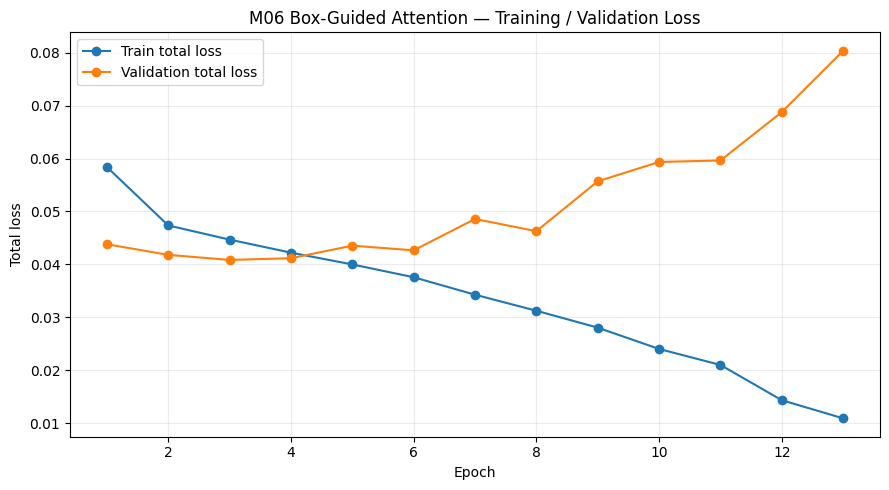

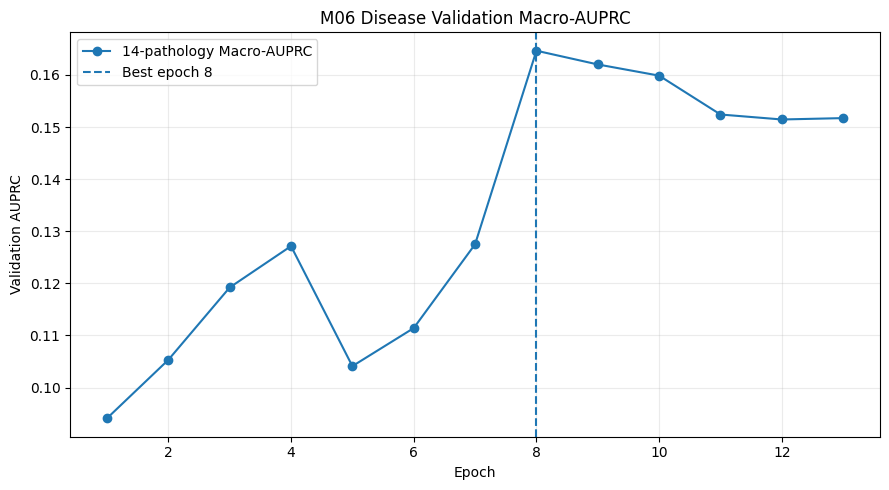

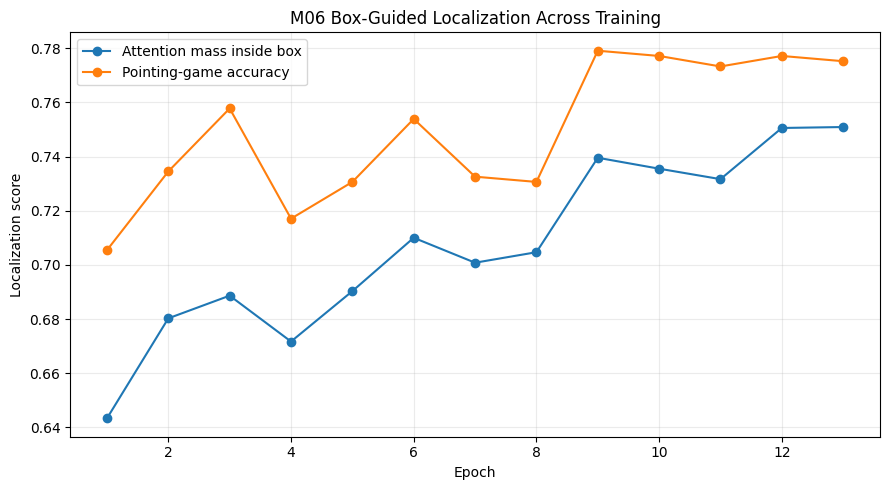

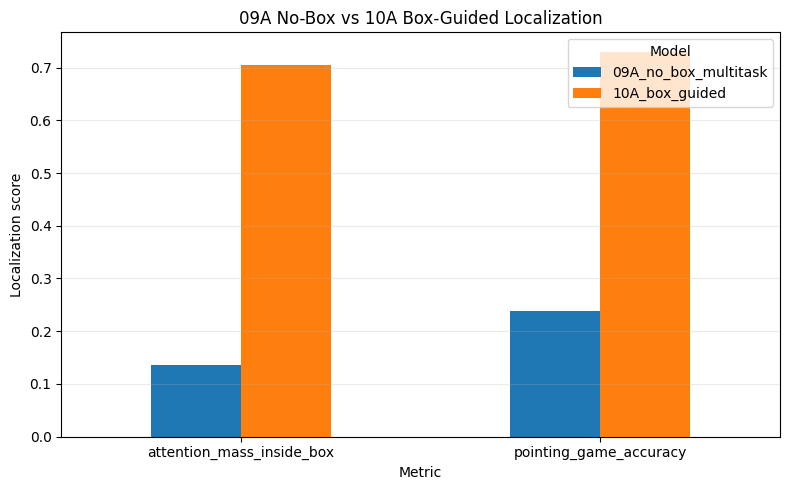

In [27]:
# ============================================================
# 30. Save scientific plots — no restricted X-rays
# ============================================================
history_df = pd.DataFrame(history)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    history_df["epoch"],
    history_df["train_total_loss"],
    marker="o",
    label="Train total loss",
)
ax.plot(
    history_df["epoch"],
    history_df["validation_total_loss"],
    marker="o",
    label="Validation total loss",
)
ax.set_xlabel("Epoch")
ax.set_ylabel("Total loss")
ax.set_title("M06 Box-Guided Attention — Training / Validation Loss")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(
    FIG_DIR / "training_validation_loss.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    history_df["epoch"],
    history_df["pathology14_macro_AUPRC"],
    marker="o",
    label="14-pathology Macro-AUPRC",
)
ax.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch {best_epoch}",
)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation AUPRC")
ax.set_title("M06 Disease Validation Macro-AUPRC")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(
    FIG_DIR / "validation_disease_auprc.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    history_df["epoch"],
    history_df["attention_mass_inside_box"],
    marker="o",
    label="Attention mass inside box",
)
ax.plot(
    history_df["epoch"],
    history_df["pointing_game_accuracy"],
    marker="o",
    label="Pointing-game accuracy",
)
ax.set_xlabel("Epoch")
ax.set_ylabel("Localization score")
ax.set_title("M06 Box-Guided Localization Across Training")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(
    FIG_DIR / "localization_by_epoch.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()

loc_plot = comparison_df.set_index("model")[
    [
        "attention_mass_inside_box",
        "pointing_game_accuracy",
    ]
].T

fig, ax = plt.subplots(figsize=(8, 5))
loc_plot.plot(
    kind="bar",
    ax=ax,
)
ax.set_ylabel("Localization score")
ax.set_xlabel("Metric")
ax.set_title("09A No-Box vs 10A Box-Guided Localization")
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Model")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    FIG_DIR / "09A_vs_10A_localization.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()


In [28]:
# ============================================================
# 31. Save experiment configuration and environment
# ============================================================
peak_gpu_memory_gb = (
    torch.cuda.max_memory_allocated() / 1024**3
    if DEVICE.type == "cuda"
    else None
)

config = {
    "experiment_id": EXPERIMENT_ID,
    "stage": "Standard_Box_Guided_Attention",
    "backbone": "ResNet50",
    "pretraining":
        "ImageNet / torchvision ResNet50_Weights.DEFAULT",
    "image_size": IMAGE_SIZE,
    "box_mask_size": BOX_MASK_SIZE,
    "disease_outputs": LABEL_COLUMNS,
    "finding_outputs": FINDING_CLASSES,
    "finding_supervision_source":
        "annotations_train.csv: class_name",
    "box_supervision_source":
        "annotations_train.csv: x_min,y_min,x_max,y_max",
    "numeric_class_id_used": False,
    "bounding_boxes_used": True,
    "box_target_type": "union_rectangle_mask_per_finding",
    "attention_type":
        "linear-head direct CAM spatial softmax",
    "box_loss_type":
        "negative_log_attention_mass_inside_box",
    "finding_loss_weight": FINDING_LOSS_WEIGHT,
    "box_loss_weight": BOX_LOSS_WEIGHT,
    "pathology_metrics_exclude": ["No finding"],
    "disease_loss": "BinaryFocalLoss",
    "finding_loss": "BinaryFocalLoss",
    "total_loss":
        "disease_focal + 0.5*finding_focal + 0.01*box_attention_loss",
    "focal_gamma": FOCAL_GAMMA,
    "optimizer": "AdamW",
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "batch_size": BATCH_SIZE,
    "max_epochs": MAX_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "seed": SEED,
    "mixed_precision": USE_AMP,
    "selection_metric":
        "validation_pathology14_macro_AUPRC",
    "localization_metrics": [
        "attention_mass_inside_box",
        "pointing_game_accuracy",
    ],
    "baseline_localization_checkpoint":
        BASELINE_EXPERIMENT_ID,
    "train_images": len(train_df),
    "validation_images": len(val_df),
    "calibration_used": False,
    "official_test_used": False,
    "split_manifest_sha256": manifest_hash,
    "augmentation": {
        "horizontal_flip": False,
        "vertical_flip": False,
        "random_affine_degrees": 5,
        "translation_fraction": 0.03,
        "scale_range": [0.95, 1.05],
        "brightness_jitter": 0.10,
        "contrast_jitter": 0.10,
        "box_masks_transformed_jointly": True,
    },
    "preprocessing": {
        "modality_lut": True,
        "voi_lut_when_available": True,
        "monochrome1_correction": True,
        "percentile_clip": [0.5, 99.5],
        "cached_grayscale_uint8": True,
        "normalization_values_preserved_from_stage09": True,
    },
}

with open(
    OUTPUT_DIR / "config.json",
    "w",
) as f:
    json.dump(config, f, indent=2)

environment_info = {
    "python": sys.version,
    "platform": platform.platform(),
    "torch": torch.__version__,
    "torchvision": torchvision.__version__,
    "pydicom": pydicom.__version__,
    "cuda_available": torch.cuda.is_available(),
    "gpu_name": (
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else None
    ),
    "peak_gpu_memory_gb": peak_gpu_memory_gb,
    "training_seconds": training_seconds,
    "training_minutes": training_seconds / 60,
    "best_epoch": int(best_epoch),
    "best_selection_metric": float(best_metric),
}

with open(
    OUTPUT_DIR / "environment_info.json",
    "w",
) as f:
    json.dump(
        environment_info,
        f,
        indent=2,
    )

split_verification = {
    "manifest_path": str(MANIFEST_PATH),
    "manifest_source": MANIFEST_SOURCE,
    "manifest_sha256": manifest_hash,
    "expected_sha256":
        EXPECTED_SPLIT_MANIFEST_SHA256,
    "verified":
        manifest_hash
        == EXPECTED_SPLIT_MANIFEST_SHA256,
    "train_images": len(train_df),
    "validation_images": len(val_df),
    "calibration_images_not_used":
        int(split_counts["calibration"]),
    "official_test_used": False,
}

with open(
    OUTPUT_DIR / "split_verification.json",
    "w",
) as f:
    json.dump(
        split_verification,
        f,
        indent=2,
    )

print(json.dumps(environment_info, indent=2))


{
  "python": "3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]",
  "platform": "Linux-6.12.90+-x86_64-with-glibc2.35",
  "torch": "2.10.0+cu128",
  "torchvision": "0.25.0+cu128",
  "pydicom": "3.0.2",
  "cuda_available": true,
  "gpu_name": "Tesla T4",
  "peak_gpu_memory_gb": 1.0506978034973145,
  "training_seconds": 777.4622631072998,
  "training_minutes": 12.957704385121664,
  "best_epoch": 8,
  "best_selection_metric": 0.16465411377808994
}


In [29]:
# ============================================================
# 32. Easy-to-read Stage-10 summary
# ============================================================
head_ap = float(
    final_groups.loc[
        final_groups["group"] == "Head",
        "macro_AUPRC",
    ].iloc[0]
)
middle_ap = float(
    final_groups.loc[
        final_groups["group"] == "Middle",
        "macro_AUPRC",
    ].iloc[0]
)
tail_ap = float(
    final_groups.loc[
        final_groups["group"] == "Tail",
        "macro_AUPRC",
    ].iloc[0]
)

baseline_loc = baseline_stats[
    "localization_summary"
]
final_loc = final_localization_summary

summary_lines = [
    "Pedi-CGAM Lite — M06 Standard Box-Guided Attention",
    "=" * 70,
    "",
    "EXPERIMENT",
    "- Shared backbone: ResNet50",
    f"- Resolution: {IMAGE_SIZE}x{IMAGE_SIZE}",
    "- Disease loss: Binary Focal Loss",
    "- Finding loss: Binary Focal Loss",
    f"- Focal gamma: {FOCAL_GAMMA:g}",
    f"- Finding loss weight: {FINDING_LOSS_WEIGHT:g}",
    f"- Box loss weight: {BOX_LOSS_WEIGHT:g}",
    f"- Seed: {SEED}",
    "- Box supervision: YES",
    "- Box guidance applies to finding attention: YES",
    "- Numeric class_id used: NO",
    "",
    "DATA SAFETY",
    "- Calibration used: NO",
    "- Official test used: NO",
    "- Restricted X-rays exported: NO",
    f"- Frozen split SHA-256: {manifest_hash}",
    "",
    "PRIMARY DISEASE RESULTS",
    (
        "- 14-pathology Macro-AUPRC: "
        f"{final_summary['pathology14_macro_AUPRC']:.6f}"
    ),
    f"- Head Macro-AUPRC: {head_ap:.6f}",
    f"- Middle Macro-AUPRC: {middle_ap:.6f}",
    f"- Tail Macro-AUPRC: {tail_ap:.6f}",
    (
        "- 14-pathology Macro-AUROC: "
        f"{final_summary['pathology14_macro_AUROC']:.6f}"
    ),
    "",
    "FINDING RESULTS",
    (
        "- Actual-36 finding Macro-AUPRC: "
        f"{final_finding_summary['actual36_macro_AUPRC']:.6f}"
    ),
    "",
    "LOCALIZATION — 09A NO BOX",
    (
        "- Attention mass inside boxes: "
        f"{baseline_loc['pair_weighted_attention_mass_inside_box']:.6f}"
    ),
    (
        "- Pointing-game accuracy: "
        f"{baseline_loc['pair_weighted_pointing_game_accuracy']:.6f}"
    ),
    "",
    "LOCALIZATION — 10C BOX GUIDED",
    (
        "- Attention mass inside boxes: "
        f"{final_loc['pair_weighted_attention_mass_inside_box']:.6f}"
    ),
    (
        "- Pointing-game accuracy: "
        f"{final_loc['pair_weighted_pointing_game_accuracy']:.6f}"
    ),
    "",
    "LOCALIZATION CHANGE",
    (
        "- Attention-mass delta: "
        f"{final_loc['pair_weighted_attention_mass_inside_box'] - baseline_loc['pair_weighted_attention_mass_inside_box']:+.6f}"
    ),
    (
        "- Pointing-game delta: "
        f"{final_loc['pair_weighted_pointing_game_accuracy'] - baseline_loc['pair_weighted_pointing_game_accuracy']:+.6f}"
    ),
    "",
    "TRAINING",
    f"- Best epoch: {best_epoch}",
    f"- Training time: {training_seconds/60:.2f} minutes",
    (
        f"- Peak GPU memory: {peak_gpu_memory_gb:.2f} GB"
        if peak_gpu_memory_gb is not None
        else "- Peak GPU memory: unavailable"
    ),
    "",
    "INTERPRETATION RULE",
    "- Disease Macro-AUPRC remains the primary checkpoint metric.",
    "- Localization must be compared directly against 09A no-box attention.",
    "- Do not claim box guidance helps unless localization evidence supports it.",
    "- Do not move to CGAM until this Stage-10 result is reviewed.",
]

summary_text = "\n".join(
    summary_lines
)

print(summary_text)

with open(
    OUTPUT_DIR / "README_RESULTS.txt",
    "w",
) as f:
    f.write(summary_text)


Pedi-CGAM Lite — M06 Standard Box-Guided Attention

EXPERIMENT
- Shared backbone: ResNet50
- Resolution: 320x320
- Disease loss: Binary Focal Loss
- Finding loss: Binary Focal Loss
- Focal gamma: 2
- Finding loss weight: 0.5
- Box loss weight: 0.01
- Seed: 42
- Box supervision: YES
- Box guidance applies to finding attention: YES
- Numeric class_id used: NO

DATA SAFETY
- Calibration used: NO
- Official test used: NO
- Restricted X-rays exported: NO
- Frozen split SHA-256: 3d2f8de854c9f61382b1ef5594264af739fcb1d3d9ca8ca9fe8d388380363770

PRIMARY DISEASE RESULTS
- 14-pathology Macro-AUPRC: 0.164654
- Head Macro-AUPRC: 0.193459
- Middle Macro-AUPRC: 0.262350
- Tail Macro-AUPRC: 0.006528
- 14-pathology Macro-AUROC: 0.789339

FINDING RESULTS
- Actual-36 finding Macro-AUPRC: 0.069701

LOCALIZATION — 09A NO BOX
- Attention mass inside boxes: 0.135367
- Pointing-game accuracy: 0.238372

LOCALIZATION — 10C BOX GUIDED
- Attention mass inside boxes: 0.704670
- Pointing-game accuracy: 0.730620

L

In [30]:
# ============================================================
# 33. Final Stage-10 integrity gate
# ============================================================
checks = pd.DataFrame([
    {
        "check": "Frozen split SHA-256 verified",
        "passed":
            manifest_hash
            == EXPECTED_SPLIT_MANIFEST_SHA256,
    },
    {
        "check": "Train count = 5,408",
        "passed": len(train_df) == 5408,
    },
    {
        "check": "Validation count = 1,159",
        "passed": len(val_df) == 1159,
    },
    {
        "check": "Disease outputs = 15",
        "passed": len(LABEL_COLUMNS) == 15,
    },
    {
        "check": "Finding outputs = 37",
        "passed": len(FINDING_CLASSES) == 37,
    },
    {
        "check": "Actual local findings = 36",
        "passed":
            len([
                x
                for x in FINDING_CLASSES
                if x != "No finding"
            ]) == 36,
    },
    {
        "check": "Numeric class_id not used",
        "passed": True,
    },
    {
        "check": "Bounding boxes used",
        "passed": True,
    },
    {
        "check": "Finding loss weight = 0.5",
        "passed":
            np.isclose(
                FINDING_LOSS_WEIGHT,
                0.5,
            ),
    },
    {
        "check": "Box loss weight = 0.01",
        "passed":
            np.isclose(
                BOX_LOSS_WEIGHT,
                0.01,
            ),
    },
    {
        "check": "09A checkpoint verified",
        "passed":
            m01_checkpoint.get("experiment_id")
            == BASELINE_EXPERIMENT_ID,
    },
    {
        "check": "09A disease metric reproduced",
        "passed":
            abs(
                baseline_ap
                - EXPECTED_M01_PATHOLOGY14_AUPRC
            )
            <= M01_REPRO_TOLERANCE,
    },
    {
        "check": "Validation has box-supervised pairs",
        "passed":
            final_localization_summary[
                "boxed_validation_image_finding_pairs"
            ] > 0,
    },
    {
        "check": "Localization metrics finite",
        "passed":
            np.isfinite(
                final_localization_summary[
                    "pair_weighted_attention_mass_inside_box"
                ]
            )
            and np.isfinite(
                final_localization_summary[
                    "pair_weighted_pointing_game_accuracy"
                ]
            ),
    },
    {
        "check": "Calibration data not used",
        "passed": True,
    },
    {
        "check": "Official test not used",
        "passed": True,
    },
    {
        "check": "No preprocessing failures",
        "passed": len(cache_failures) == 0,
    },
    {
        "check": "Best checkpoint exists",
        "passed": BEST_MODEL_PATH.exists(),
    },
    {
        "check": "Disease validation predictions = 1,159",
        "passed":
            len(predictions_df) == 1159,
    },
    {
        "check": "Finding validation predictions = 1,159",
        "passed":
            len(finding_predictions_df) == 1159,
    },
    {
        "check": "Disease primary metric finite",
        "passed":
            np.isfinite(
                final_summary[
                    "pathology14_macro_AUPRC"
                ]
            ),
    },
])

checks["status"] = checks[
    "passed"
].map({
    True: "PASS",
    False: "REVIEW",
})

display(checks)

checks.to_csv(
    OUTPUT_DIR
    / "final_integrity_status.csv",
    index=False,
)

FINAL_STATUS = (
    "PASS"
    if checks["passed"].all()
    else "REVIEW"
)

print("\n" + "=" * 75)
print(
    "M06 STANDARD BOX-GUIDED ATTENTION FINAL STATUS:",
    FINAL_STATUS,
)

if FINAL_STATUS == "PASS":
    print(
        "✅ M06 BOX-GUIDED ATTENTION EXPERIMENT COMPLETED SUCCESSFULLY"
    )
else:
    print(
        "⚠️ REVIEW BEFORE ANY BOX-WEIGHT SWEEP OR CGAM"
    )

print("=" * 75)


,check,passed,status
0,Frozen split SHA-256 verified,True,PASS
1,"Train count = 5,408",True,PASS
2,"Validation count = 1,159",True,PASS
3,Disease outputs = 15,True,PASS
4,Finding outputs = 37,True,PASS
5,Actual local findings = 36,True,PASS
6,Numeric class_id not used,True,PASS
7,Bounding boxes used,True,PASS
8,Finding loss weight = 0.5,True,PASS
9,Box loss weight = 0.01,True,PASS



M06 STANDARD BOX-GUIDED ATTENTION FINAL STATUS: PASS
✅ M06 BOX-GUIDED ATTENTION EXPERIMENT COMPLETED SUCCESSFULLY


In [31]:
# ============================================================
# 34. List scientific output files
# ============================================================
print("M06 output files:")
print("-" * 80)

for p in sorted(OUTPUT_DIR.rglob("*")):
    if p.is_file():
        print(
            f"{p.relative_to(OUTPUT_DIR)} "
            f"| {p.stat().st_size/(1024**2):.3f} MB"
        )


M06 output files:
--------------------------------------------------------------------------------
README_RESULTS.txt | 0.001 MB
best_model.pth | 90.393 MB
config.json | 0.003 MB
environment_info.json | 0.000 MB
figures/09A_vs_10A_localization.png | 0.071 MB
figures/localization_by_epoch.png | 0.131 MB
figures/training_validation_loss.png | 0.106 MB
figures/validation_disease_auprc.png | 0.102 MB
final_integrity_status.csv | 0.001 MB
model_summary.txt | 0.011 MB
split_verification.json | 0.001 MB
tables/09A_vs_10A_comparison.csv | 0.000 MB
tables/baseline09A_localization_per_finding.csv | 0.002 MB
tables/baseline09A_localization_summary.csv | 0.000 MB
tables/box_annotation_summary.csv | 0.000 MB
tables/finding_class_map.csv | 0.001 MB
tables/finding_label_frequencies.csv | 0.001 MB
tables/finding_per_class_metrics.csv | 0.002 MB
tables/finding_summary_metrics.csv | 0.000 MB
tables/finding_validation_predictions.csv | 0.586 MB
tables/head_middle_tail_metrics.csv | 0.000 MB
tables/locali

# Final one-click Kaggle export

The final ZIP intentionally contains:

- checkpoint
- aggregate experiment configuration
- training history
- disease/finding validation predictions
- classification metrics
- localization metrics
- 09A-vs-10A comparison
- scientific plots containing **no raw X-rays**

It must **not** contain:

- DICOM files
- raw cached images
- box masks
- raw box-coordinate tables


In [32]:
# ============================================================
# 35. ZIP THE ENTIRE M06 EXPERIMENT FOLDER INTO ONE FILE
# ============================================================
ZIP_FILE = Path(
    "/kaggle/working/M06_BoxGuidedAttention_Lambda001_Seed42_All_Outputs.zip"
)

if ZIP_FILE.exists():
    ZIP_FILE.unlink()

source_files = sorted(
    p
    for p in OUTPUT_DIR.rglob("*")
    if p.is_file()
)

if not source_files:
    raise RuntimeError(
        "No experiment outputs found to package."
    )

# Restricted-data guards.
blocked_extensions = {
    ".dcm",
    ".dicom",
    ".npy",
    ".npz",
}

for p in source_files:
    lower = p.name.lower()
    if p.suffix.lower() in blocked_extensions:
        raise RuntimeError(
            f"STOP: restricted/raw array file detected in output folder: {p}"
        )
    if "box_coordinates" in lower:
        raise RuntimeError(
            f"STOP: raw box-coordinate file detected in output folder: {p}"
        )

with zipfile.ZipFile(
    ZIP_FILE,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
    compresslevel=6,
) as zf:
    for p in source_files:
        rel = p.relative_to(OUTPUT_DIR)
        arcname = Path(EXPERIMENT_ID) / rel
        zf.write(
            p,
            arcname=str(arcname),
        )

with zipfile.ZipFile(
    ZIP_FILE,
    "r",
) as zf:
    archive_names = zf.namelist()
    corrupt_entry = zf.testzip()

if corrupt_entry is not None:
    raise RuntimeError(
        f"ZIP integrity failure at entry: {corrupt_entry}"
    )

expected_names = {
    str(
        Path(EXPERIMENT_ID)
        / p.relative_to(OUTPUT_DIR)
    )
    for p in source_files
}

missing_from_zip = (
    expected_names
    - set(archive_names)
)

if missing_from_zip:
    raise RuntimeError(
        "ZIP is missing experiment outputs: "
        + ", ".join(
            sorted(missing_from_zip)[:20]
        )
    )

important_outputs = [
    "best_model.pth",
    "config.json",
    "environment_info.json",
    "training_history.csv",
    "validation_predictions.csv",
    "summary_metrics.csv",
    "per_class_metrics.csv",
    "head_middle_tail_metrics.csv",
    "finding_per_class_metrics.csv",
    "finding_summary_metrics.csv",
    "finding_validation_predictions.csv",
    "localization_per_finding.csv",
    "localization_summary.csv",
    "baseline09A_localization_per_finding.csv",
    "baseline09A_localization_summary.csv",
    "09A_vs_10A_comparison.csv",
    "final_integrity_status.csv",
    "README_RESULTS.txt",
]

print("\nImportant output verification:")

for name in important_outputs:
    found = any(
        x.endswith("/" + name)
        for x in archive_names
    )
    print(
        ("✅" if found else "⚠️"),
        name,
    )

print(
    "\n✅ M06 COMPLETE OUTPUT ZIP CREATED"
)
print("File:", ZIP_FILE)
print("Archived files:", len(source_files))
print(
    f"ZIP size: "
    f"{ZIP_FILE.stat().st_size/(1024**2):.2f} MB"
)
print("ZIP integrity: PASS")
print("DICOM/raw cache files included: NO")
print("\nDownload this ONE ZIP from Kaggle Output.")



Important output verification:
✅ best_model.pth
✅ config.json
✅ environment_info.json
✅ training_history.csv
✅ validation_predictions.csv
✅ summary_metrics.csv
✅ per_class_metrics.csv
✅ head_middle_tail_metrics.csv
✅ finding_per_class_metrics.csv
✅ finding_summary_metrics.csv
✅ finding_validation_predictions.csv
✅ localization_per_finding.csv
✅ localization_summary.csv
✅ baseline09A_localization_per_finding.csv
✅ baseline09A_localization_summary.csv
✅ 09A_vs_10A_comparison.csv
✅ final_integrity_status.csv
✅ README_RESULTS.txt

✅ M06 COMPLETE OUTPUT ZIP CREATED
File: /kaggle/working/M06_BoxGuidedAttention_Lambda001_Seed42_All_Outputs.zip
Archived files: 28
ZIP size: 84.61 MB
ZIP integrity: PASS
DICOM/raw cache files included: NO

Download this ONE ZIP from Kaggle Output.


## What to send back

After the notebook finishes, send:

`M06_BoxGuidedAttention_Lambda001_Seed42_All_Outputs.zip`

I will review:

- integrity checks
- exact reproduction of the 09A baseline
- convergence and overfitting
- best epoch
- 14-pathology Macro-AUPRC
- head / middle / tail AUPRC
- finding Macro-AUPRC
- box-attention loss
- attention mass inside radiologist boxes
- pointing-game accuracy
- **09A no-box vs 10A box-guided localization improvement**
- training time and peak GPU memory

### Do not move to CGAM yet

After this result we will compare **09A no-box**, **10A (`λbox = 0.10`)**, **10B (`λbox = 0.05`)**, and **10C (`λbox = 0.01`)** on disease Macro-AUPRC and localization. If 0.01 recovers disease performance while retaining meaningful localization, we can freeze Stage 10. If classification is still substantially worse, stop coefficient tuning and redesign the spatial-supervision schedule/loss before CGAM.

Only after the standard box-guided baseline is scientifically stable should we introduce **Pedi-CGAM Lite**.
